In [ ]:
import pandas as pd
df = pd.read_csv("glovo_ops_data_final.csv")
df.head()

,order_id,customer_id,courier_id,store_address_id,store_name,vertical,gtv,delivery_fee,description,activation_time_local,...,pickup_time_local,delivery_time_local,tranport_type,rating,bad_rating_reason,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation
0,32.0,700734,441.0,10887.0,Pharmacie,WALL - Partner,19.97,4.9,1 x DOLIPRANE 1000mg - 8 comprimés\n1 x IMODIU...,2019-10-01 09:21:34.000,...,2019-10-01 09:34:55.904,2019-10-01 09:50:02.000,MOTORBIKE,5.0,NaN,48.861046,2.275441,48.855068,2.283378,66
1,29.0,1648235,239.0,3705.0,Starbucks,WALL - NonPartner,10.50,4.9,"1 x Caffe Latte - Tall, Espresso Roast Class...",2019-10-01 09:18:30.000,...,2019-10-01 09:36:02.133,2019-10-01 09:47:39.000,BICYCLE,NaN,NaN,48.871578,2.304495,48.867017,2.292787,40
2,292.0,13527080,351.0,1035.0,Starbucks,WALL - NonPartner,10.35,4.9,Venti Latte Vanille Glace avec seulement 2 pom...,2019-10-01 15:04:50.000,...,2019-10-01 15:25:37.131,2019-10-01 15:34:52.000,MOTORBIKE,5.0,NaN,48.855461,2.360776,48.866713,2.364773,29
3,743.0,275173,391.0,NaN,NaN,COURIER,6.60,6.6,Lunettes,2019-10-02 10:08:38.000,...,2019-10-02 10:30:24.559,2019-10-02 10:50:13.000,MOTORBIKE,NaN,NaN,48.859665,2.285694,48.884335,2.259989,54
4,838.0,1105241,263.0,51106.0,Franprix,WALL - Partner,13.10,3.9,"1 x Emmental rape 29% - Franprix - 3x35g - 1,4...",2019-10-02 12:12:09.000,...,2019-10-02 12:31:21.010,2019-10-02 12:38:04.000,MOTORBIKE,5.0,NaN,48.863417,2.361240,48.868087,2.371050,77




**ESTIMATED TIME OF ARRIVAL**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [ ]:
df = pd.read_csv("glovo_ops_data_final.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63646 entries, 0 to 63645
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   order_id                     63646 non-null  float64
 1   customer_id                  63646 non-null  int64  
 2   courier_id                   63646 non-null  float64
 3   store_address_id             52018 non-null  float64
 4   store_name                   52018 non-null  object 
 5   vertical                     63646 non-null  object 
 6   gtv                          63646 non-null  float64
 7   delivery_fee                 63646 non-null  float64
 8   description                  63614 non-null  object 
 9   activation_time_local        63646 non-null  object 
 10  courier_started_order_local  63642 non-null  object 
 11  pickup_time_local            63646 non-null  object 
 12  delivery_time_local          63646 non-null  object 
 13  tranport_type   

# EDA

## Variables tipo Object

Variables Object:
* Cuatro variables de tiempo:
  * **activation_time_local**
  * **courier_started_order_local**
  * **pickup_time_local**
  * **delivery_time_local**
* f

In [ ]:
df.select_dtypes(include="object").head(3)

,store_name,vertical,description,activation_time_local,courier_started_order_local,pickup_time_local,delivery_time_local,tranport_type,bad_rating_reason
0,Pharmacie,WALL - Partner,1 x DOLIPRANE 1000mg - 8 comprimés\n1 x IMODIU...,2019-10-01 09:21:34.000,2019-10-01 09:19:06.342,2019-10-01 09:34:55.904,2019-10-01 09:50:02.000,MOTORBIKE,NaN
1,Starbucks,WALL - NonPartner,"1 x Caffe Latte - Tall, Espresso Roast Class...",2019-10-01 09:18:30.000,2019-10-01 09:28:04.560,2019-10-01 09:36:02.133,2019-10-01 09:47:39.000,BICYCLE,NaN
2,Starbucks,WALL - NonPartner,Venti Latte Vanille Glace avec seulement 2 pom...,2019-10-01 15:04:50.000,2019-10-01 15:04:28.032,2019-10-01 15:25:37.131,2019-10-01 15:34:52.000,MOTORBIKE,NaN


In [ ]:
object_var = ["tranport_type","vertical"]

for i in object_var:
  print(df[i].unique())

['MOTORBIKE' 'BICYCLE' 'CAR' 'WALKER']
['WALL - Partner' 'WALL - NonPartner' 'COURIER']


## Variables tipo numerical

* **Order_id** eliminada

In [ ]:
df.select_dtypes(include=["float","int"]).head(3)

,order_id,customer_id,courier_id,store_address_id,gtv,delivery_fee,rating,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation
0,32.0,700734,441.0,10887.0,19.97,4.9,5.0,48.861046,2.275441,48.855068,2.283378,66
1,29.0,1648235,239.0,3705.0,10.50,4.9,NaN,48.871578,2.304495,48.867017,2.292787,40
2,292.0,13527080,351.0,1035.0,10.35,4.9,5.0,48.855461,2.360776,48.866713,2.364773,29


In [ ]:
df.select_dtypes(include=["float","int"]).describe()

,order_id,customer_id,courier_id,store_address_id,gtv,delivery_fee,rating,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation
count,63646.000000,6.364600e+04,63646.000000,52018.000000,63646.000000,63646.000000,26784.000000,63646.000000,63646.000000,63646.000000,63646.000000,63646.000000
mean,42599.441033,7.339444e+06,281.304183,42794.678477,23.475663,5.569971,4.820154,48.864058,2.321907,48.864130,2.318299,77.772633
std,24605.798877,8.219375e+06,140.223522,41522.426586,17.365952,3.661555,0.827880,0.017255,0.037469,0.020156,0.040682,36.107480
min,1.000000,1.154000e+03,1.000000,911.000000,0.000000,0.000000,1.000000,48.803918,2.221335,48.794007,2.211807,20.000000
25%,21298.250000,1.094467e+06,165.000000,7113.000000,12.900000,3.900000,5.000000,48.852065,2.289582,48.850450,2.287040,51.000000
50%,42649.500000,3.209173e+06,303.000000,23886.000000,18.390000,3.900000,5.000000,48.866397,2.322111,48.865338,2.314835,73.000000
75%,63922.750000,1.167532e+07,403.000000,78604.000000,28.500000,6.900000,5.000000,48.876436,2.349763,48.878739,2.348273,98.000000
max,85126.000000,2.986686e+07,534.000000,136345.000000,346.620000,23.900000,5.000000,48.916104,2.437825,48.928184,2.443143,239.000000


In [ ]:
df.select_dtypes(include=['object']).columns

Index(['store_name', 'vertical', 'description', 'activation_time_local',
       'courier_started_order_local', 'pickup_time_local',
       'delivery_time_local', 'tranport_type', 'bad_rating_reason'],
      dtype='object')

/tmp/ipykernel_7437/2285811266.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')
/tmp/ipykernel_7437/2285811266.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')
/tmp/ipykernel_7437/2285811266.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')
/tmp/ipykernel_7437/2285811266.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and 

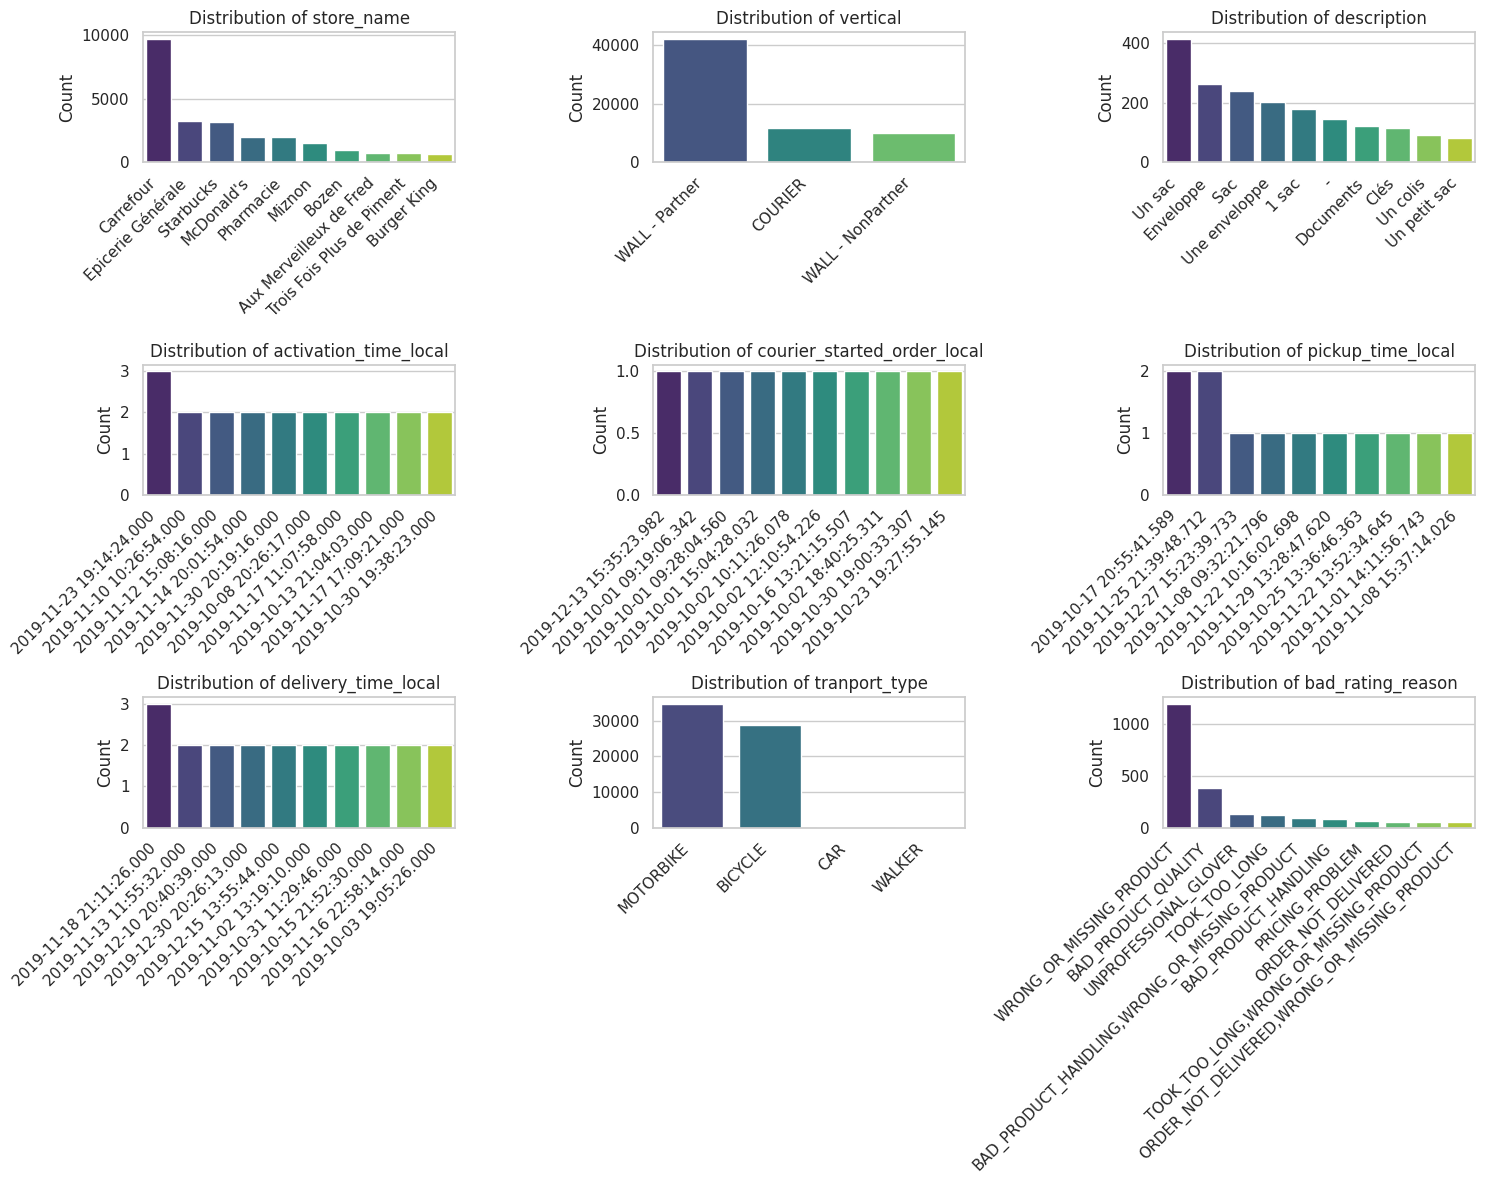

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get object type columns. This was previously identified.
object_columns = df.select_dtypes(include=['object']).columns.tolist()

# Determine the number of subplots and grid layout
n_cols = 3 # Number of columns for the subplot grid
n_rows = (len(object_columns) + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4)) # Adjust figure size dynamically

for i, col in enumerate(object_columns):
    plt.subplot(n_rows, n_cols, i + 1)

    # Count value frequencies and take top N values (e.g., top 10)
    # This prevents overcrowded plots for columns with many unique values
    top_values = df[col].value_counts().nlargest(10)
    sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')

    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel('') # Remove x-label as title is descriptive
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

plt.tight_layout() # Adjust subplot params for a tight layout
plt.show()

# FEATURE ENGINEERING

+ Eliminar las columnas que no aportan datos


In [ ]:
df = df.drop(["order_id","customer_id","bad_rating_reason","rating","description"], axis=1)

In [ ]:
import pandas as pd
import numpy as np

# Asumimos que el DataFrame df_glovo ya está cargado en tu entorno

def haversine_vectorized(lat1, lon1, lat2, lon2):
    # Radio de la Tierra en kilómetros
    R = 6371.0

    # Convertir todas las coordenadas de grados a radianes
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Calcular las diferencias
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Aplicar la fórmula matemática
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))

    # Multiplicar por el radio para obtener la distancia final en kilómetros
    return R * c

# Crear la nueva columna en el dataset
df['distance_km'] = haversine_vectorized(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['delivery_latitude'],
    df['delivery_longitude']
)

# Visualizar las primeras filas para comprobar que se ha calculado correctamente
print(df[['pickup_latitude', 'pickup_longitude', 'delivery_latitude', 'delivery_longitude', 'distance_km']].head())

   pickup_latitude  pickup_longitude  delivery_latitude  delivery_longitude  \
0        48.861046          2.275441          48.855068            2.283378   
1        48.871578          2.304495          48.867017            2.292787   
2        48.855461          2.360776          48.866713            2.364773   
3        48.859665          2.285694          48.884335            2.259989   
4        48.863417          2.361240          48.868087            2.371050   

   distance_km  
0     0.882526  
1     0.995245  
2     1.284852  
3     3.325588  
4     0.885714  


In [ ]:
df

,courier_id,store_address_id,store_name,vertical,gtv,delivery_fee,activation_time_local,courier_started_order_local,pickup_time_local,delivery_time_local,tranport_type,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation,distance_km
0,441.0,10887.0,Pharmacie,WALL - Partner,19.97,4.9,2019-10-01 09:21:34.000,2019-10-01 09:19:06.342,2019-10-01 09:34:55.904,2019-10-01 09:50:02.000,MOTORBIKE,48.861046,2.275441,48.855068,2.283378,66,0.882526
1,239.0,3705.0,Starbucks,WALL - NonPartner,10.50,4.9,2019-10-01 09:18:30.000,2019-10-01 09:28:04.560,2019-10-01 09:36:02.133,2019-10-01 09:47:39.000,BICYCLE,48.871578,2.304495,48.867017,2.292787,40,0.995245
2,351.0,1035.0,Starbucks,WALL - NonPartner,10.35,4.9,2019-10-01 15:04:50.000,2019-10-01 15:04:28.032,2019-10-01 15:25:37.131,2019-10-01 15:34:52.000,MOTORBIKE,48.855461,2.360776,48.866713,2.364773,29,1.284852
3,391.0,NaN,NaN,COURIER,6.60,6.6,2019-10-02 10:08:38.000,2019-10-02 10:11:26.078,2019-10-02 10:30:24.559,2019-10-02 10:50:13.000,MOTORBIKE,48.859665,2.285694,48.884335,2.259989,54,3.325588
4,263.0,51106.0,Franprix,WALL - Partner,13.10,3.9,2019-10-02 12:12:09.000,2019-10-02 12:10:54.226,2019-10-02 12:31:21.010,2019-10-02 12:38:04.000,MOTORBIKE,48.863417,2.361240,48.868087,2.371050,77,0.885714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63641,92.0,60709.0,Aux Merveilleux de Fred,WALL - NonPartner,30.30,6.9,2019-11-23 10:28:51.000,2019-11-23 10:38:12.088,2019-11-23 11:04:19.883,2019-11-23 11:20:22.000,MOTORBIKE,48.844928,2.237055,48.819739,2.257546,96,3.177201
63642,97.0,13198.0,Benson Kfé,WALL - Partner,21.90,3.9,2019-10-02 12:00:35.000,2019-10-02 12:02:50.366,2019-10-02 12:12:21.561,2019-10-02 12:37:06.000,MOTORBIKE,48.878383,2.285877,48.892718,2.238183,103,3.834308
63643,59.0,NaN,NaN,COURIER,11.90,11.9,2019-12-25 13:39:32.000,2019-12-25 13:36:20.396,2019-12-25 13:49:32.407,2019-12-25 14:05:28.000,BICYCLE,48.865610,2.342366,48.880040,2.332157,48,1.769770
63644,402.0,NaN,NaN,COURIER,12.90,12.9,2019-12-06 13:02:10.000,2019-12-06 13:23:13.630,2019-12-06 13:30:59.134,2019-12-06 14:03:18.000,BICYCLE,48.874409,2.332547,48.886671,2.284347,109,3.779193


## Fechas

In [ ]:
date_variables = ["delivery_time_local","pickup_time_local","activation_time_local","courier_started_order_local"]

for i in date_variables:
  df[i]=pd.to_datetime(df[i])

In [ ]:
df["ETA"] = df['delivery_time_local'] - df['activation_time_local']

In [ ]:
df.head(5)

,courier_id,store_address_id,store_name,vertical,gtv,delivery_fee,activation_time_local,courier_started_order_local,pickup_time_local,delivery_time_local,tranport_type,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation,distance_km,ETA
0,441.0,10887.0,Pharmacie,WALL - Partner,19.97,4.9,2019-10-01 09:21:34,2019-10-01 09:19:06.342,2019-10-01 09:34:55.904,2019-10-01 09:50:02,MOTORBIKE,48.861046,2.275441,48.855068,2.283378,66,0.882526,0 days 00:28:28
1,239.0,3705.0,Starbucks,WALL - NonPartner,10.50,4.9,2019-10-01 09:18:30,2019-10-01 09:28:04.560,2019-10-01 09:36:02.133,2019-10-01 09:47:39,BICYCLE,48.871578,2.304495,48.867017,2.292787,40,0.995245,0 days 00:29:09
2,351.0,1035.0,Starbucks,WALL - NonPartner,10.35,4.9,2019-10-01 15:04:50,2019-10-01 15:04:28.032,2019-10-01 15:25:37.131,2019-10-01 15:34:52,MOTORBIKE,48.855461,2.360776,48.866713,2.364773,29,1.284852,0 days 00:30:02
3,391.0,NaN,NaN,COURIER,6.60,6.6,2019-10-02 10:08:38,2019-10-02 10:11:26.078,2019-10-02 10:30:24.559,2019-10-02 10:50:13,MOTORBIKE,48.859665,2.285694,48.884335,2.259989,54,3.325588,0 days 00:41:35
4,263.0,51106.0,Franprix,WALL - Partner,13.10,3.9,2019-10-02 12:12:09,2019-10-02 12:10:54.226,2019-10-02 12:31:21.010,2019-10-02 12:38:04,MOTORBIKE,48.863417,2.361240,48.868087,2.371050,77,0.885714,0 days 00:25:55


In [ ]:
import pandas as pd
import numpy as np
import holidays

# Asegurarnos de que la columna es tipo datetime
df['activation_time_local'] = pd.to_datetime(df['activation_time_local'])

# 1. Extraer la hora y el día de la semana (Lunes=0, Domingo=6)
df['hour_of_day'] = df['activation_time_local'].dt.hour
df['day_of_week'] = df['activation_time_local'].dt.dayofweek

# 2. Crear una variable binaria (Flag) para los fines de semana
df['is_weekend'] = df['day_of_week'].isin([4, 5, 6]).astype(int)

# 3. Crear una variable binaria para los días festivos
# Nota: Instalad la librería si no la tenéis con:
!pip install holidays
calendario_festivos = holidays.country_holidays('FR') # FR para Francia, cambiar a 'ES' si fuera España
df['is_holiday'] = df['activation_time_local'].dt.date.apply(lambda x: 1 if x in calendario_festivos else 0)

# Comprobar las nuevas variables
print(df[['activation_time_local', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_holiday']].head(20))

   activation_time_local  hour_of_day  day_of_week  is_weekend  is_holiday
0    2019-10-01 09:21:34            9            1           0           0
1    2019-10-01 09:18:30            9            1           0           0
2    2019-10-01 15:04:50           15            1           0           0
3    2019-10-02 10:08:38           10            2           0           0
4    2019-10-02 12:12:09           12            2           0           0
5    2019-10-16 13:14:17           13            2           0           0
6    2019-10-02 18:39:48           18            2           0           0
7    2019-10-30 18:58:55           18            2           0           0
8    2019-10-23 19:25:32           19            2           0           0
9    2019-10-10 10:01:33           10            3           0           0
10   2019-10-10 12:49:54           12            3           0           0
11   2019-10-03 13:51:12           13            3           0           0
12   2019-10-03 17:02:01 

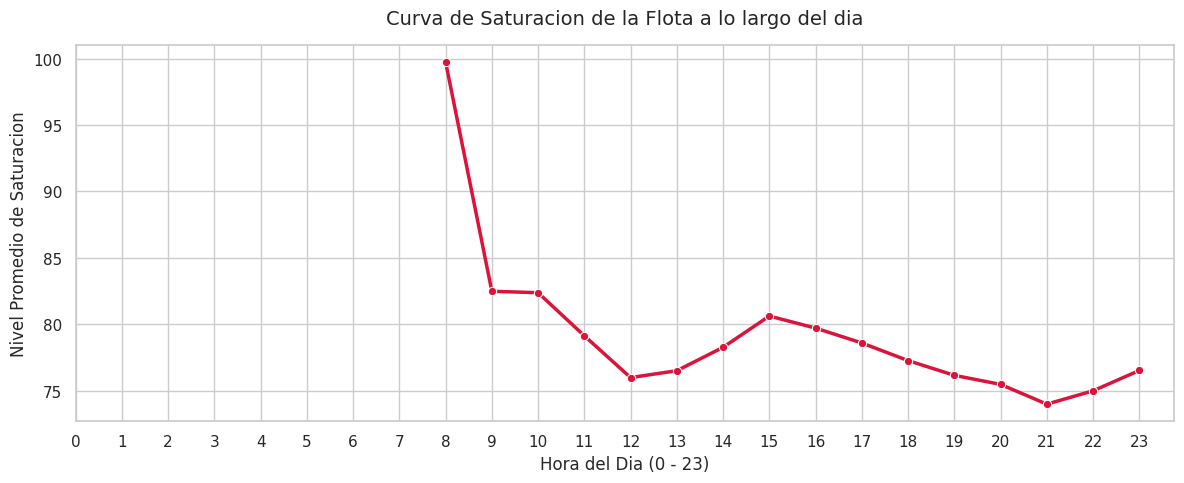

/tmp/ipykernel_7437/1306435015.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='day_of_week', y='saturation', palette='viridis', estimator=np.median, errorbar=None)


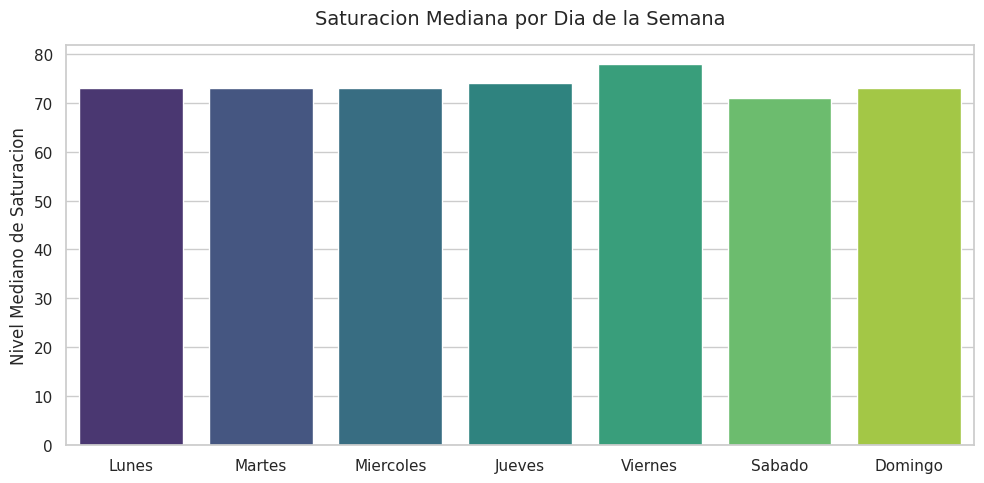

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# Gráfico 1: Saturación promedio a lo largo de las 24 horas del día
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='hour_of_day', y='saturation', estimator='mean',
             errorbar=None, marker='o', linewidth=2.5, color='crimson')
plt.title('Curva de Saturacion de la Flota a lo largo del dia', fontsize=14, pad=15)
plt.xlabel('Hora del Dia (0 - 23)', fontsize=12)
plt.ylabel('Nivel Promedio de Saturacion', fontsize=12)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
dias_semana = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']

# Añadimos estimator='median' (o np.median) para calcular la mediana en lugar del promedio
sns.barplot(data=df, x='day_of_week', y='saturation', palette='viridis', estimator=np.median, errorbar=None)

plt.title('Saturacion Mediana por Dia de la Semana', fontsize=14, pad=15)
plt.xticks(ticks=range(7), labels=dias_semana)
plt.xlabel('')
plt.ylabel('Nivel Mediano de Saturacion', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_7437/4033285128.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(data=df, x='day_of_week', palette='viridis')


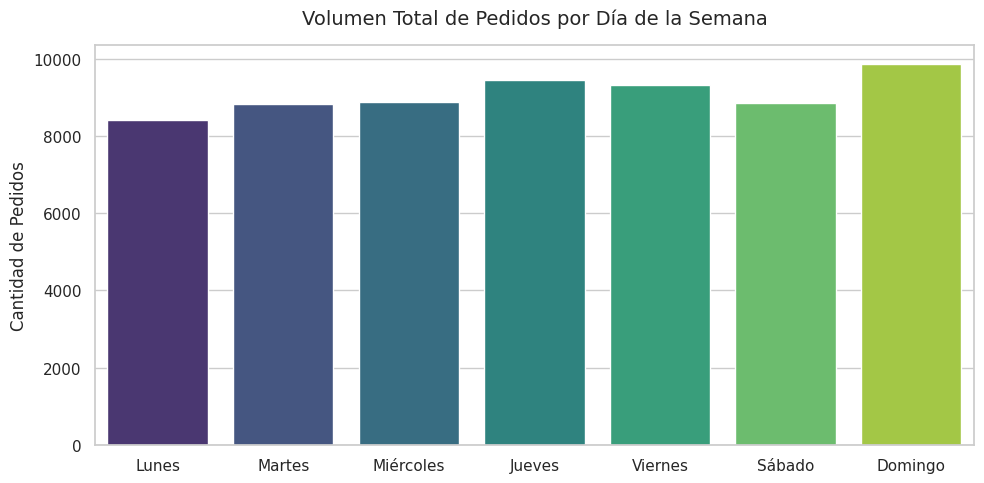

/tmp/ipykernel_7437/4033285128.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(data=df, x='month', palette='magma')


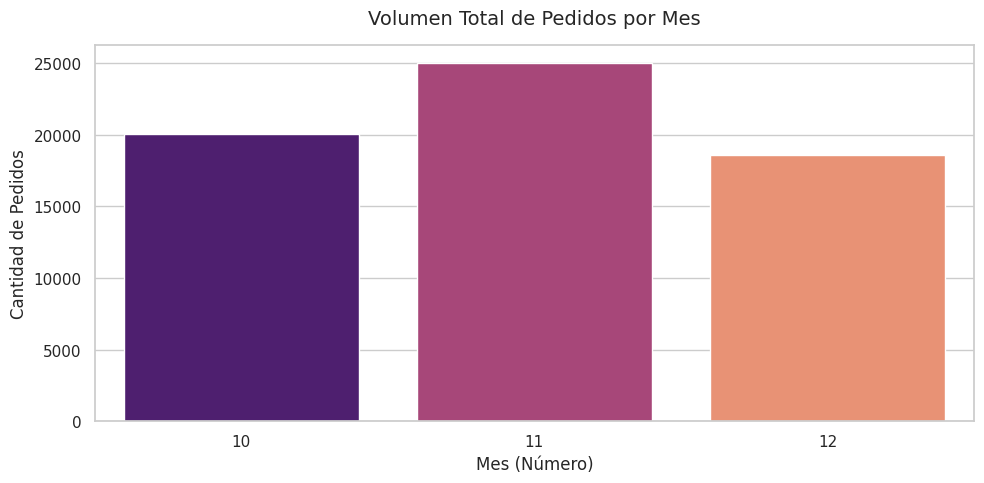

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# 1. Asegurarnos de tener la columna del mes extraída de la fecha original
df['month'] = df['activation_time_local'].dt.month

# ==============================================================================
# GRÁFICO 1: Volumen de pedidos por Día de la Semana
# ==============================================================================
plt.figure(figsize=(10, 5))

# countplot para contar pedidos por día
ax1 = sns.countplot(data=df, x='day_of_week', palette='viridis')

# Etiquetas profesionales en lugar de números (0=Lunes, 6=Domingo)
dias_semana = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
plt.title('Volumen Total de Pedidos por Día de la Semana', fontsize=14, pad=15)
plt.xticks(ticks=range(7), labels=dias_semana)
plt.xlabel('')
plt.ylabel('Cantidad de Pedidos', fontsize=12)

plt.tight_layout()
plt.show()


# ==============================================================================
# GRÁFICO 2: Volumen de pedidos por Mes
# ==============================================================================
plt.figure(figsize=(10, 5))

# countplot para contar pedidos por mes
ax2 = sns.countplot(data=df, x='month', palette='magma')

plt.title('Volumen Total de Pedidos por Mes', fontsize=14, pad=15)
plt.xlabel('Mes (Número)', fontsize=12)
plt.ylabel('Cantidad de Pedidos', fontsize=12)

plt.tight_layout()
plt.show()

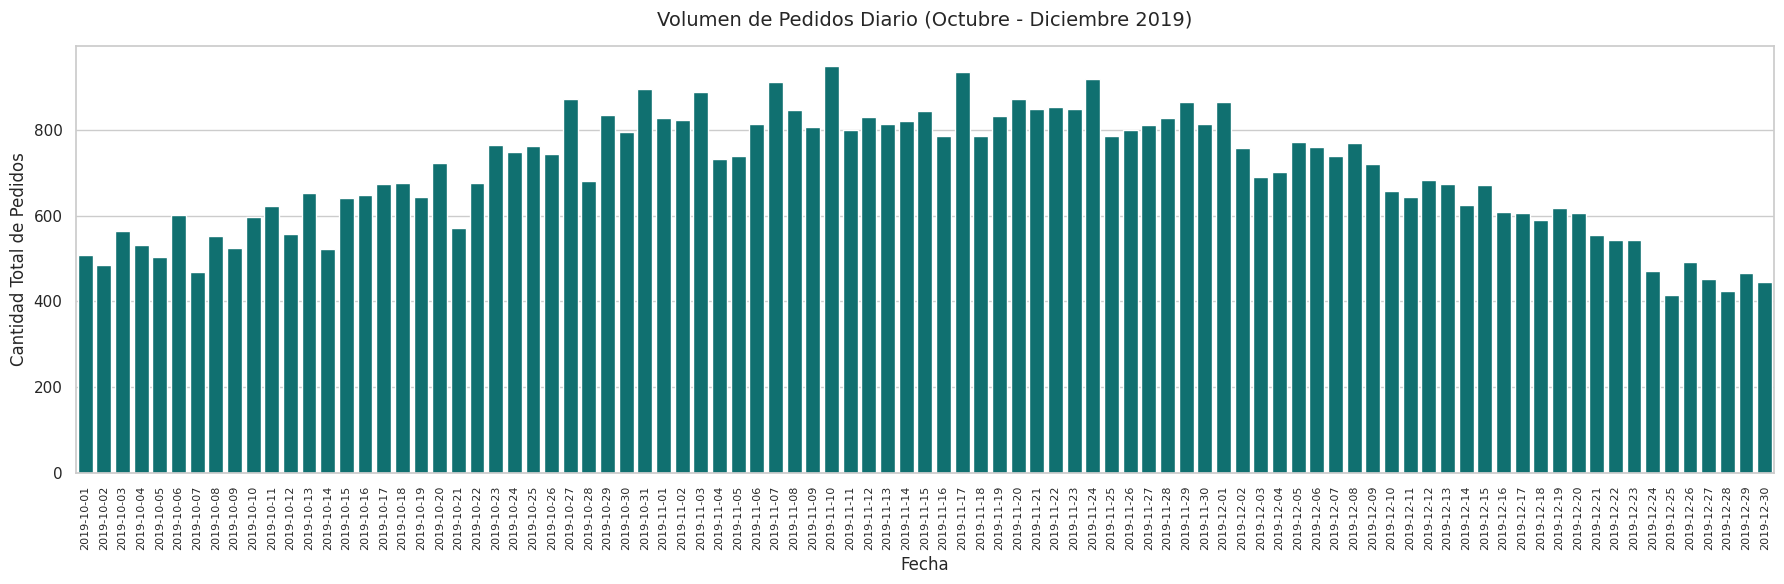

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# 1. Extraer solo la fecha (año-mes-día) descartando la hora
df['date'] = df['activation_time_local'].dt.date

# 2. Agrupar y contar la cantidad de pedidos por cada día exacto
pedidos_por_dia = df.groupby('date').size().reset_index(name='cantidad_pedidos')

# 3. Crear el gráfico de barras (Barplot)
plt.figure(figsize=(18, 6)) # Hacemos la figura un poco más ancha para acomodar los 90 días

# Utilizamos color='teal' para mantener tu paleta, o puedes usar palette='viridis' si prefieres gradiente
sns.barplot(data=pedidos_por_dia, x='date', y='cantidad_pedidos', color='teal')

plt.title('Volumen de Pedidos Diario (Octubre - Diciembre 2019)', fontsize=14, pad=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidad Total de Pedidos', fontsize=12)

# Rotar las fechas del eje X a 90 grados y reducir un poco la fuente para que quepan bien
plt.xticks(rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

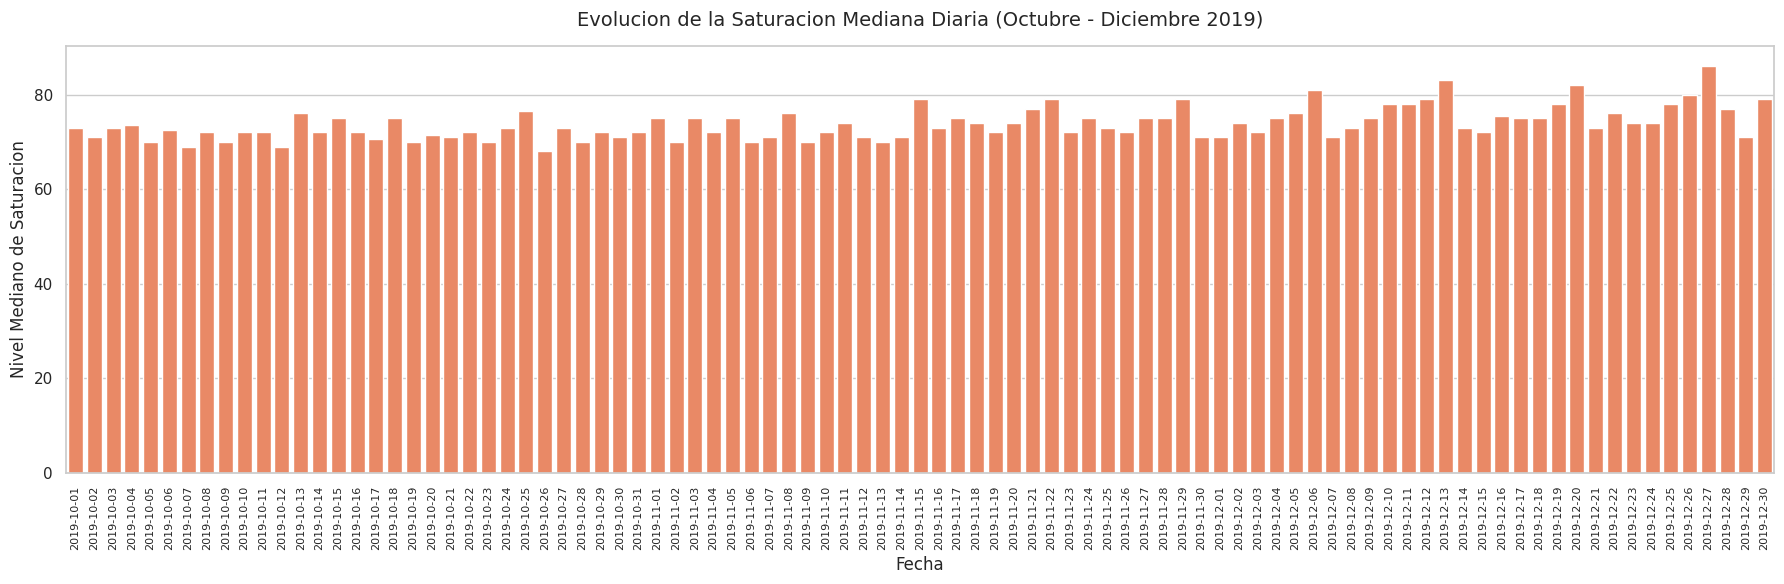

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# 1. Asegurarnos de tener la fecha extraída
df['date'] = df['activation_time_local'].dt.date

# 2. Agrupar y calcular la saturación MEDIANA por cada día exacto
saturacion_por_dia = df.groupby('date')['saturation'].median().reset_index()

# 3. Crear el gráfico de barras (Barplot)
plt.figure(figsize=(18, 6)) # Ampliamos el ancho para acomodar bien todos los días

# Usamos barplot manteniendo el color coral para diferenciarlo de los pedidos
sns.barplot(data=saturacion_por_dia, x='date', y='saturation', color='coral')

plt.title('Evolucion de la Saturacion Mediana Diaria (Octubre - Diciembre 2019)', fontsize=14, pad=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Nivel Mediano de Saturacion', fontsize=12)

# Rotar las fechas a 90 grados y reducir la fuente para facilitar la lectura
plt.xticks(rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# 0. Asegurarnos de que ETA_seconds existe (por si eliminaste la celda que lo creaba)
df['ETA_seconds'] = (pd.to_datetime(df['delivery_time_local']) - pd.to_datetime(df['activation_time_local'])).dt.total_seconds()

In [ ]:
df.describe()

,courier_id,store_address_id,gtv,delivery_fee,activation_time_local,courier_started_order_local,pickup_time_local,delivery_time_local,pickup_latitude,pickup_longitude,...,delivery_longitude,saturation,distance_km,ETA,hour_of_day,day_of_week,is_weekend,is_holiday,month,ETA_seconds
count,63646.000000,52018.000000,63646.000000,63646.000000,63646,63642,63646,63646,63646.000000,63646.000000,...,63646.000000,63646.000000,63646.000000,63646,63646.000000,63646.000000,63646.000000,63646.000000,63646.000000,63646.000000
mean,281.304183,42794.678477,23.475663,5.569971,2019-11-15 07:38:13.059784192,2019-11-15 07:43:17.625992192,2019-11-15 07:58:29.891374592,2019-11-15 08:16:20.736747520,48.864058,2.321907,...,2.318299,77.772633,2.461211,0 days 00:38:07.676963202,15.649954,3.075417,0.440688,0.032084,10.976652,2287.676963
min,1.000000,911.000000,0.000000,0.000000,2019-10-01 08:32:08,2019-10-01 08:58:42.736000,2019-10-01 09:08:09.822000,2019-10-01 09:25:32,48.803918,2.221335,...,2.211807,20.000000,0.006302,0 days 00:03:38,8.000000,0.000000,0.000000,0.000000,10.000000,218.000000
25%,165.000000,7113.000000,12.900000,3.900000,2019-10-26 21:53:42.249999872,2019-10-26 21:57:26.710749952,2019-10-26 22:11:18.798500096,2019-10-26 22:29:35.249999872,48.852065,2.289582,...,2.287040,51.000000,1.241154,0 days 00:27:24,12.000000,1.000000,0.000000,0.000000,10.000000,1644.000000
50%,303.000000,23886.000000,18.390000,3.900000,2019-11-15 11:45:57,2019-11-15 11:54:24.040999936,2019-11-15 12:10:04.322999808,2019-11-15 12:30:12.500000,48.866397,2.322111,...,2.314835,73.000000,2.092532,0 days 00:35:06,16.000000,3.000000,0.000000,0.000000,11.000000,2106.000000
75%,403.000000,78604.000000,28.500000,6.900000,2019-12-04 15:53:41.750000128,2019-12-04 15:57:44.593250048,2019-12-04 16:13:22.659250176,2019-12-04 16:35:34.249999872,48.876436,2.349763,...,2.348273,98.000000,3.257730,0 days 00:45:20,19.000000,5.000000,1.000000,0.000000,12.000000,2720.000000
max,534.000000,136345.000000,346.620000,23.900000,2019-12-30 23:22:58,2019-12-30 23:22:25.338000,2019-12-30 23:49:03.435000,2019-12-30 23:59:29,48.916104,2.437825,...,2.443143,239.000000,14.179735,0 days 02:16:36,23.000000,6.000000,1.000000,1.000000,12.000000,8196.000000
std,140.223522,41522.426586,17.365952,3.661555,NaN,NaN,NaN,NaN,0.017255,0.037469,...,0.040682,36.107480,1.686053,0 days 00:15:38.360898804,3.909906,1.994611,0.496473,0.176224,0.778505,938.360899


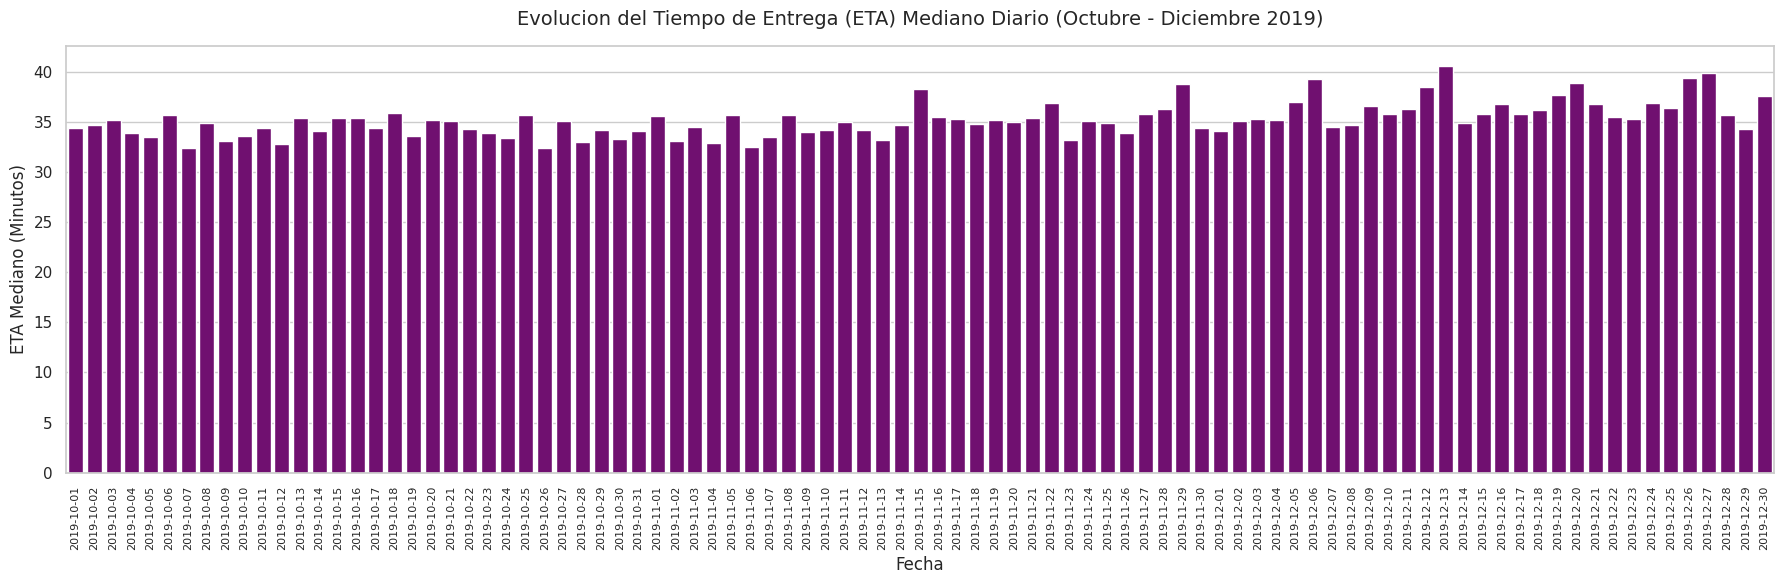

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# 1. Asegurarnos de tener la columna 'date'
df['date'] = df['activation_time_local'].dt.date

# 2. Asegurarnos de tener el tiempo de entrega en minutos
# Si utilizaste 'ETA_seconds' en el paso anterior, lo dividimos por 60.
if 'delivery_time_minutes' not in df.columns:
    df['delivery_time_minutes'] = df['ETA_seconds'] / 60

# 3. Agrupar y calcular el ETA (tiempo de entrega) MEDIANO por cada día
eta_por_dia = df.groupby('date')['delivery_time_minutes'].median().reset_index()

# 4. Crear el gráfico de barras (Barplot)
plt.figure(figsize=(18, 6))

# Utilizamos color morado para contrastar con los anteriores
sns.barplot(data=eta_por_dia, x='date', y='delivery_time_minutes', color='purple')

plt.title('Evolucion del Tiempo de Entrega (ETA) Mediano Diario (Octubre - Diciembre 2019)', fontsize=14, pad=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('ETA Mediano (Minutos)', fontsize=12)

# Rotar las fechas a 90 grados y reducir la fuente para facilitar la lectura
plt.xticks(rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

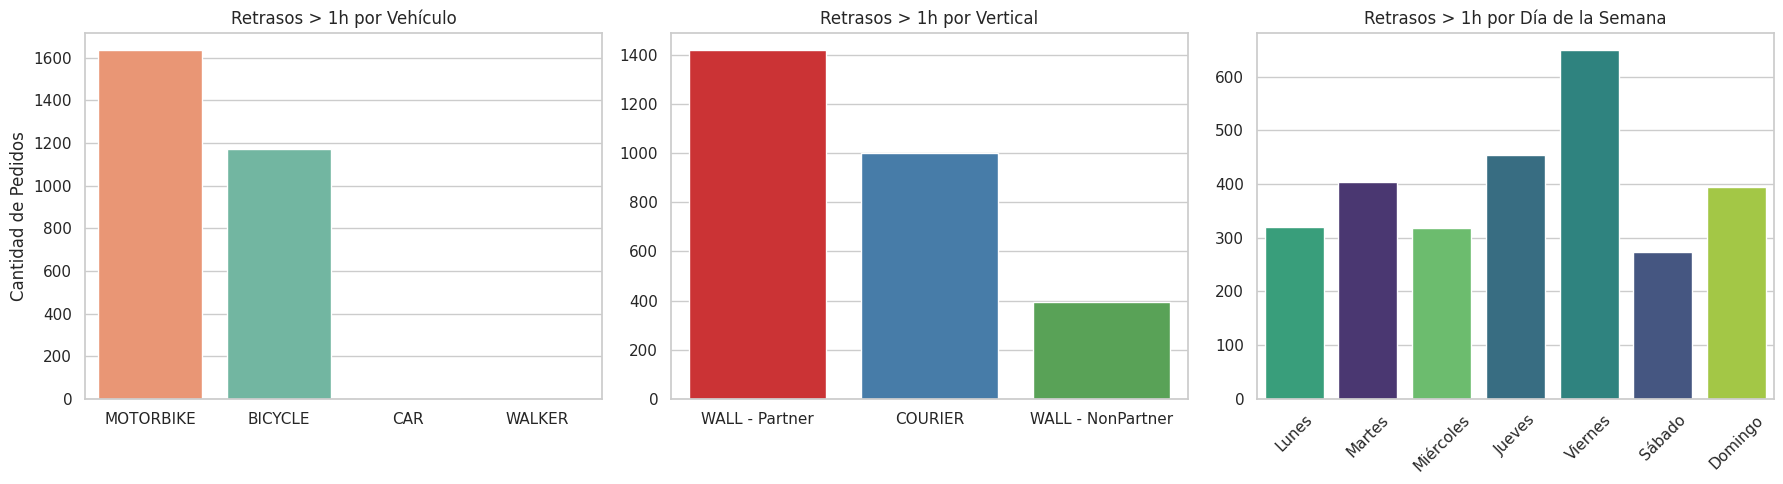

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo
sns.set_theme(style="whitegrid")

# 1. SOLUCIÓN AL VALUE ERROR: Asegurarnos de crear 'day_name' antes de filtrar
df['day_of_week'] = df['activation_time_local'].dt.dayofweek
dias_map = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
df['day_name'] = df['day_of_week'].map(dias_map)

# Calcular el tiempo en minutos (por si acaso no estaba en memoria)
if 'delivery_time_minutes' not in df.columns:
    df['delivery_time_minutes'] = df['ETA_seconds'] / 60

# Filtrar los pedidos extremos (> 60 mins) AHORA SÍ CON TODAS LAS COLUMNAS
df_extremos = df[df['delivery_time_minutes'] > 70].copy()

# 2. Preparar una figura con 3 subgráficos horizontales
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# SOLUCIÓN A LOS FUTURE WARNINGS: Añadimos hue=... y legend=False en todos los gráficos

# Gráfico A: Por Vehículo
sns.countplot(data=df_extremos, x='tranport_type', hue='tranport_type', palette='Set2',
              ax=axes[0], order=df_extremos['tranport_type'].value_counts().index, legend=False)
axes[0].set_title('Retrasos > 1h por Vehículo')
axes[0].set_ylabel('Cantidad de Pedidos')
axes[0].set_xlabel('')

# Gráfico B: Por Vertical
if 'vertical' in df_extremos.columns:
    sns.countplot(data=df_extremos, x='vertical', hue='vertical', palette='Set1',
                  ax=axes[1], order=df_extremos['vertical'].value_counts().index, legend=False)
    axes[1].set_title('Retrasos > 1h por Vertical')
    axes[1].set_ylabel('')
    axes[1].set_xlabel('')

# Gráfico C: Por Día de la semana
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
sns.countplot(data=df_extremos, x='day_name', hue='day_name', palette='viridis',
              ax=axes[2], order=orden_dias, legend=False)
axes[2].set_title('Retrasos > 1h por Día de la Semana')
axes[2].set_ylabel('')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Nos aseguramos de que la columna esté calculada en minutos
if 'delivery_time_minutes' not in df.columns:
    df['delivery_time_minutes'] = df['ETA_seconds'] / 60

# 2. Aplicamos la condición (> 60) y sumamos los casos que la cumplen
total_retrasos_graves = (df['delivery_time_minutes'] > 60).sum()

# 3. Imprimimos el resultado
print(f"Total de pedidos con más de 1 hora de entrega: {total_retrasos_graves}")

Total de pedidos con más de 1 hora de entrega: 5643


# Eliminar los incidentes operativos (> 60 minutos) para entrenar el modelo predictivo
df_clean = df_final[df_final['ETA_seconds'] <= 3600].copy()

# Ahora defines X e Y usando el dataset limpio
X_xgb = df_clean.drop('ETA_seconds', axis=1)
y_xgb = df_clean['ETA_seconds']

# Continúa con el train_test_split y el entrenamiento de XGBoost como hiciste antes...

/tmp/ipykernel_7437/3897841883.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='delivery_time_minutes', y=nombre_columna_transporte,


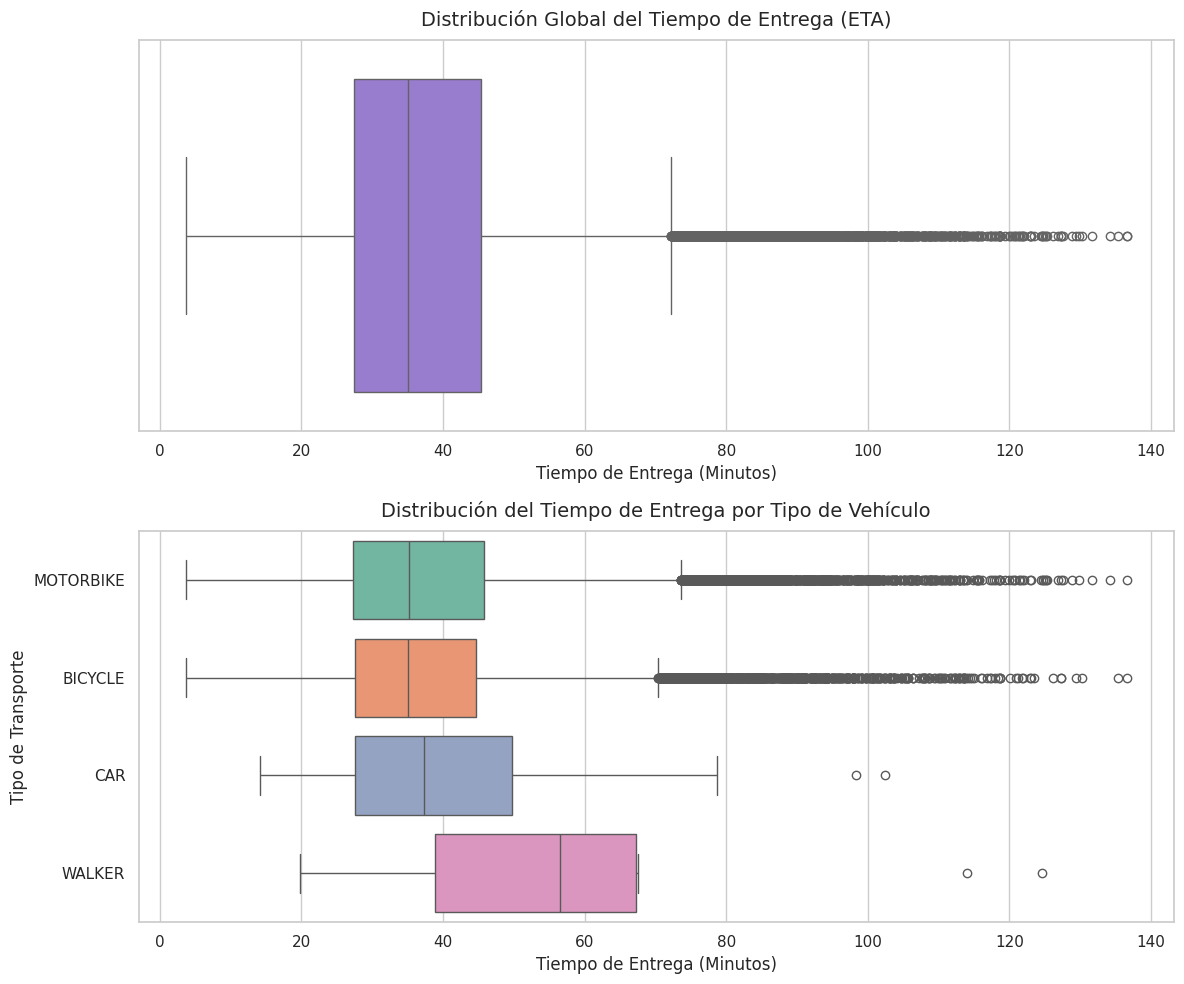

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# Crear una figura con dos subgráficos (uno arriba y otro abajo)
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 1. Gráfico de Caja Global
sns.boxplot(data=df, x='delivery_time_minutes', color='mediumpurple', ax=axes[0])
axes[0].set_title('Distribución Global del Tiempo de Entrega (ETA)', fontsize=14, pad=10)
axes[0].set_xlabel('Tiempo de Entrega (Minutos)', fontsize=12)

# 2. Gráfico de Caja segmentado por Tipo de Transporte (si tienes la columna)
# Nota: Asegúrate de que la columna se llame 'transport_type' o 'tranport_type' según tu dataset
nombre_columna_transporte = 'tranport_type' # Ajusta esto si tu columna tiene otro nombre

if nombre_columna_transporte in df.columns:
    sns.boxplot(data=df, x='delivery_time_minutes', y=nombre_columna_transporte,
                palette='Set2', ax=axes[1])
    axes[1].set_title('Distribución del Tiempo de Entrega por Tipo de Vehículo', fontsize=14, pad=10)
    axes[1].set_xlabel('Tiempo de Entrega (Minutos)', fontsize=12)
    axes[1].set_ylabel('Tipo de Transporte', fontsize=12)
else:
    axes[1].set_visible(False) # Oculta el segundo gráfico si no existe la columna

plt.tight_layout()
plt.show()

/tmp/ipykernel_7437/1264025858.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hour_of_day', palette='Blues_r')


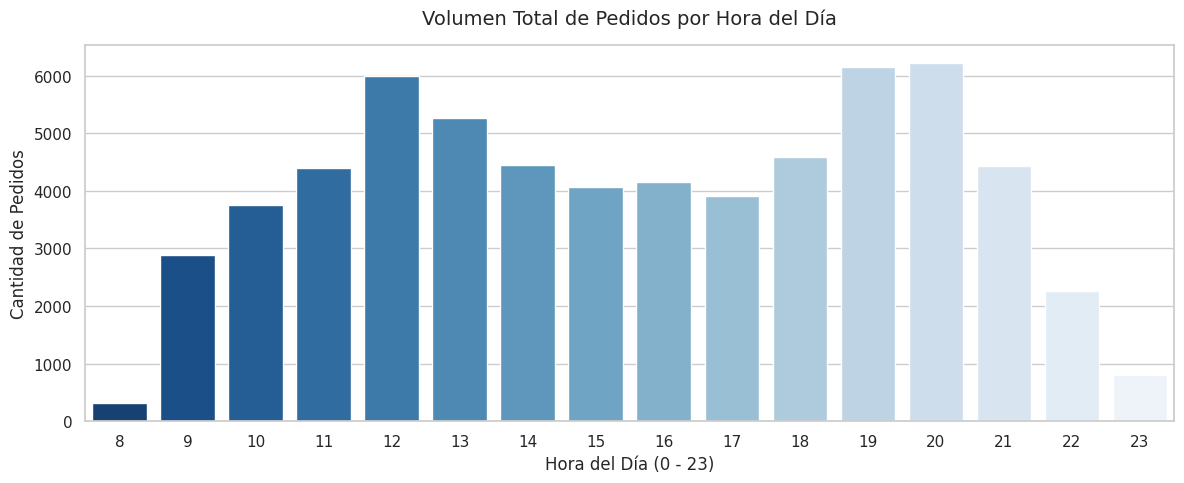

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# Gráfico: Cantidad total de pedidos por hora del día
plt.figure(figsize=(12, 5))

# countplot cuenta automáticamente cuántas veces aparece cada hora en el dataset
sns.countplot(data=df, x='hour_of_day', palette='Blues_r')

plt.title('Volumen Total de Pedidos por Hora del Día', fontsize=14, pad=15)
plt.xlabel('Hora del Día (0 - 23)', fontsize=12)
plt.ylabel('Cantidad de Pedidos', fontsize=12)

# Aseguramos que se muestren todas las horas en el eje X
# Nota: Si en tus datos no hay pedidos de madrugada (ej. 3 AM o 4 AM),
# Seaborn solo mostrará las horas con datos.
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd



# 1. Filtro de Outliers lógicos
# Eliminamos pedidos que tardaron menos de 5 minutos (probables errores/cancelaciones rápidas)
# y los que tardaron más de 120 minutos (2 horas, que es un caso extremo y atípico para ML)
df_limpio = df[(df['ETA_seconds'] >= 300) & (df['ETA_seconds'] <= 7200)].copy()

# 2. Selección final de características (Features)
# Mantenemos las variables numéricas clave y las categóricas que vamos a transformar
columnas_modelo = [
    'ETA_seconds', 'distance_km', 'gtv', 'delivery_fee', 'saturation',
    'hour_of_day', 'day_of_week', 'is_weekend', 'is_holiday',
    'tranport_type', 'vertical'
]

# Creamos el dataset final solo con las columnas que necesitamos
df_final = df_limpio[columnas_modelo].copy()

# 3. One-Hot Encoding (Variables Dummy)
# Convertimos 'tranport_type' y 'vertical' en columnas binarias
df_final = pd.get_dummies(df_final, columns=['tranport_type', 'vertical'], drop_first=True)

# Veamos cómo ha quedado la forma final del dataset
print(f"Filas originales: {len(df)}")
print(f"Filas tras limpieza: {len(df_final)}")
print("\nVariables finales para entrenar:")
print(df_final.columns.tolist())

Filas originales: 63646
Filas tras limpieza: 63600

Variables finales para entrenar:
['ETA_seconds', 'distance_km', 'gtv', 'delivery_fee', 'saturation', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_holiday', 'tranport_type_CAR', 'tranport_type_MOTORBIKE', 'tranport_type_WALKER', 'vertical_WALL - NonPartner', 'vertical_WALL - Partner']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# 1. Separar variables predictoras (X) del objetivo (y)
X = df_final.drop('ETA_seconds', axis=1)
y = df_final['ETA_seconds']

# 2. Dividir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenar el Modelo Simple (Regresión Lineal)
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

# Hacer predicciones y calcular MAE (convertido a minutos)
predicciones_lineal = modelo_lineal.predict(X_test)
mae_lineal = mean_absolute_error(y_test, predicciones_lineal) / 60

# 4. Entrenar el Modelo Complejo (Random Forest)
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)

# Hacer predicciones y calcular MAE (convertido a minutos)
predicciones_rf = modelo_rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, predicciones_rf) / 60

# 5. Comparativa final
print("--- Comparativa de Rendimiento ---")
print(f"Error MAE (Regresión Lineal): {mae_lineal:.2f} minutos")
print(f"Error MAE (Random Forest):  {mae_rf:.2f} minutos")

--- Comparativa de Rendimiento ---
Error MAE (Regresión Lineal): 7.72 minutos
Error MAE (Random Forest):  7.28 minutos


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

# Asegurarnos de tener las predicciones del Random Forest usando los datos de prueba
predicciones_rf = modelo_rf.predict(X_test)

# 1. MAE (Error Medio Absoluto) convertido a minutos
mae = mean_absolute_error(y_test, predicciones_rf) / 60

# 2. MSE (Error Cuadrático Medio)
# Se suele dejar en su unidad original al cuadrado (segundos al cuadrado)
mse = mean_squared_error(y_test, predicciones_rf)

# 3. RMSE (Raíz del Error Cuadrático Medio) convertido a minutos
rmse = np.sqrt(mse) / 60

# 4. MAPE (Error Porcentual Absoluto Medio)
# Multiplicamos por 100 para visualizarlo como porcentaje
mape = mean_absolute_percentage_error(y_test, predicciones_rf) * 100

# 5. R2 (Coeficiente de Determinación)
r2 = r2_score(y_test, predicciones_rf)

print("=== TODAS LAS MÉTRICAS DE EVALUACIÓN (RANDOM FOREST) ===")
print(f"1. MAE (Desviación promedio):          {mae:.2f} minutos")
print(f"2. RMSE (Penalización de extremos):    {rmse:.2f} minutos")
print(f"3. MAPE (Desviación porcentual):       {mape:.2f} %")
print(f"4. R2 (Varianza explicada):            {r2 * 100:.2f} %")
print(f"5. MSE (Error cuadrático bruto):       {mse:.2f} segundos al cuadrado")

=== TODAS LAS MÉTRICAS DE EVALUACIÓN (RANDOM FOREST) ===
1. MAE (Desviación promedio):          7.28 minutos
2. RMSE (Penalización de extremos):    9.12 minutos
3. MAPE (Desviación porcentual):       21.81 %
4. R2 (Varianza explicada):            65.56 %
5. MSE (Error cuadrático bruto):       299484.37 segundos al cuadrado


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Partimos del DataFrame original tal como lo leímos del CSV
df_raw = pd.read_csv("glovo_ops_data_final.csv")

# 2. Solo calculamos el Target (ETA_seconds), ya que no venía de serie
df_raw['delivery_time_local'] = pd.to_datetime(df_raw['delivery_time_local'])
df_raw['activation_time_local'] = pd.to_datetime(df_raw['activation_time_local'])
df_raw['ETA_seconds'] = (df_raw['delivery_time_local'] - df_raw['activation_time_local']).dt.total_seconds()

# Eliminamos filas donde el ETA sea nulo para que el modelo no falle
df_raw = df_raw.dropna(subset=['ETA_seconds'])

# 3. Seleccionamos SOLO las variables numéricas originales
# (Excluimos categoricas, fechas, e IDs para que el modelo pueda funcionar)
columnas_crudas = ['gtv', 'delivery_fee', 'saturation',
                   'pickup_latitude', 'pickup_longitude',
                   'delivery_latitude', 'delivery_longitude']

# Rellenamos nulos con 0 (una imputación "mala" típica de datos crudos)
X_raw = df_raw[columnas_crudas].fillna(0)
y_raw = df_raw['ETA_seconds']

# 4. Dividir los datos (Train/Test)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

# 5. Entrenar el Modelo Crudo
print("Entrenando Modelo Crudo (Baseline)...")
rf_raw = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_raw.fit(X_train_raw, y_train_raw)

# 6. Evaluar
pred_raw = rf_raw.predict(X_test_raw)

mae_raw = mean_absolute_error(y_test_raw, pred_raw) / 60
rmse_raw = np.sqrt(mean_squared_error(y_test_raw, pred_raw)) / 60
r2_raw = r2_score(y_test_raw, pred_raw)

print("\n=== RENDIMIENTO DEL MODELO CRUDO (SIN FEATURE ENGINEERING) ===")
print(f"MAE  (Error Promedio):      {mae_raw:.2f} minutos")
print(f"RMSE (Penalización grave):  {rmse_raw:.2f} minutos")
print(f"R2   (Varianza explicada):  {r2_raw * 100:.2f} %")

Entrenando Modelo Crudo (Baseline)...

=== RENDIMIENTO DEL MODELO CRUDO (SIN FEATURE ENGINEERING) ===
MAE  (Error Promedio):      7.12 minutos
RMSE (Penalización grave):  8.92 minutos
R2   (Varianza explicada):  68.07 %


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Definir las columnas crudas estrictamente numéricas y SIN coordenadas
columnas_crudas_sin_gps = ['gtv', 'delivery_fee', 'saturation']

# 2. Preparar los datos (X e y)
X_raw_sin_gps = df_raw[columnas_crudas_sin_gps].fillna(0)
y_raw = df_raw['ETA_seconds']

# 3. Dividir en Entrenamiento y Prueba
X_train_sg, X_test_sg, y_train_sg, y_test_sg = train_test_split(X_raw_sin_gps, y_raw, test_size=0.2, random_state=42)

# 4. Entrenar el modelo
print("Entrenando Modelo Crudo SIN Coordenadas...")
rf_raw_sg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_raw_sg.fit(X_train_sg, y_train_sg)

# 5. Evaluar las predicciones
pred_raw_sg = rf_raw_sg.predict(X_test_sg)

mae_raw_sg = mean_absolute_error(y_test_sg, pred_raw_sg) / 60
rmse_raw_sg = np.sqrt(mean_squared_error(y_test_sg, pred_raw_sg)) / 60
r2_raw_sg = r2_score(y_test_sg, pred_raw_sg)

print("\n=== RENDIMIENTO DEL MODELO CRUDO (SIN COORDENADAS) ===")
print(f"MAE  (Error Promedio):      {mae_raw_sg:.2f} minutos")
print(f"RMSE (Penalización grave):  {rmse_raw_sg:.2f} minutos")
print(f"R2   (Varianza explicada):  {r2_raw_sg * 100:.2f} %")

Entrenando Modelo Crudo SIN Coordenadas...

=== RENDIMIENTO DEL MODELO CRUDO (SIN COORDENADAS) ===
MAE  (Error Promedio):      7.85 minutos
RMSE (Penalización grave):  9.91 minutos
R2   (Varianza explicada):  60.64 %


In [ ]:
# Instalar xgboost si tu Colab no lo tiene por defecto (casi siempre lo tiene)
# !pip install xgboost

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Asegurarnos de usar el dataset refinado (df_final) sin coordenadas crudas
X_xgb = df_final.drop('ETA_seconds', axis=1)
y_xgb = df_final['ETA_seconds']

# 2. Dividir en Entrenamiento y Prueba
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)

# 3. Inicializar el modelo XGBoost
# Usamos hiperparámetros estándar pero efectivos
print("Entrenando Modelo XGBoost sobre datos refinados...")
modelo_xgb = XGBRegressor(
    n_estimators=100,       # Número de árboles secuenciales
    learning_rate=0.1,      # Qué tan agresivamente corrige los errores
    max_depth=5,            # Profundidad de cada árbol (evita sobreajuste)
    random_state=42,
    n_jobs=-1
)

# 4. Entrenar el modelo
modelo_xgb.fit(X_train_xgb, y_train_xgb)

# 5. Hacer predicciones
predicciones_xgb = modelo_xgb.predict(X_test_xgb)

# 6. Calcular métricas en minutos
mae_xgb = mean_absolute_error(y_test_xgb, predicciones_xgb) / 60
rmse_xgb = np.sqrt(mean_squared_error(y_test_xgb, predicciones_xgb)) / 60
r2_xgb = r2_score(y_test_xgb, predicciones_xgb)

print("\n=== RENDIMIENTO DEL MODELO XGBOOST (CON FEATURE ENGINEERING) ===")
print(f"MAE  (Error Promedio):      {mae_xgb:.2f} minutos")
print(f"RMSE (Penalización grave):  {rmse_xgb:.2f} minutos")
print(f"R2   (Varianza explicada):  {r2_xgb * 100:.2f} %")

Entrenando Modelo XGBoost sobre datos refinados...

=== RENDIMIENTO DEL MODELO XGBOOST (CON FEATURE ENGINEERING) ===
MAE  (Error Promedio):      7.06 minutos
RMSE (Penalización grave):  8.85 minutos
R2   (Varianza explicada):  67.54 %


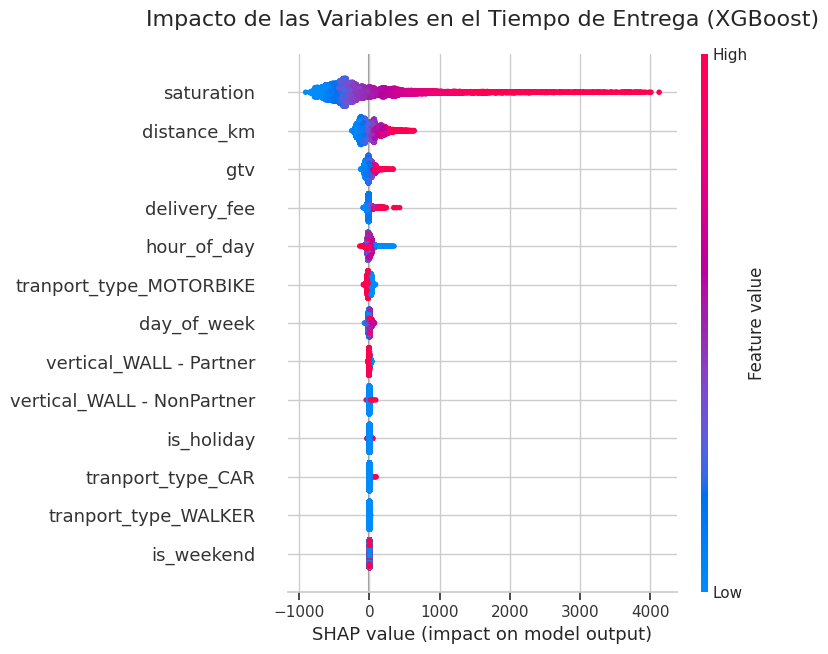

In [ ]:
# 1. Instalar la librería SHAP (necesario en Colab)
!pip install shap

import shap
import matplotlib.pyplot as plt

# 2. Inicializar el explicador matemático con tu modelo XGBoost
# Usamos TreeExplainer, que está súper optimizado para modelos basados en árboles
explainer = shap.TreeExplainer(modelo_xgb)

# 3. Calcular los valores SHAP para el conjunto de prueba
# (Nota: Si el dataset es gigante, esto puede tardar un minuto)
shap_values = explainer.shap_values(X_test_xgb)

# 4. Generar el Gráfico de Resumen (Summary Plot)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_xgb, show=False)
plt.title('Impacto de las Variables en el Tiempo de Entrega (XGBoost)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Crear el dataset "Limpio" (Flujo A: Operativa Normal de negocio)
# Nos quedamos solo con los pedidos que tardaron 60 minutos o menos
df_clean = df[df['delivery_time_minutes'] <= 60].copy()

print(f"Total de pedidos originales: {len(df)}")
print(f"Pedidos retenidos para el modelo predictivo (<= 60 min): {len(df_clean)}")
print(f"Incidentes aislados para el equipo de Operaciones (> 60 min): {len(df) - len(df_clean)}\n")

# 2. Definir las variables (Features) extraídas de tu análisis SHAP previo
columnas_features = [
    'saturation', 'distance_km', 'gtv', 'delivery_fee',
    'hour_of_day', 'tranport_type_MOTORBIKE', 'day_of_week',
    'vertical_WALL - Partner', 'vertical_WALL - NonPartner',
    'is_holiday', 'tranport_type_CAR', 'tranport_type_WALKER', 'is_weekend'
]

# Verificamos que todas las columnas existan en df_clean para evitar errores de sintaxis
features_reales = [col for col in columnas_features if col in df_clean.columns]

X = df_clean[features_reales]
y = df_clean['delivery_time_minutes']

# 3. Dividir en conjunto de Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Entrenar el nuevo XGBoost "Limpio"
print("Entrenando Modelo XGBoost sobre datos limpios...")
modelo_xgb_limpio = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1 # Usa todos los núcleos del procesador para ir más rápido
)
modelo_xgb_limpio.fit(X_train, y_train)

# 5. Generar predicciones y calcular las nuevas métricas
predicciones = modelo_xgb_limpio.predict(X_test)

mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))
r2 = r2_score(y_test, predicciones)

print("\n=== RENDIMIENTO DEL MODELO XGBOOST (SIN OUTLIERS) ===")
print(f"MAE  (Error Promedio):      {mae:.2f} minutos")
print(f"RMSE (Penalización grave):  {rmse:.2f} minutos")
print(f"R2   (Varianza explicada):  {r2*100:.2f} %")

Total de pedidos originales: 63646
Pedidos retenidos para el modelo predictivo (<= 60 min): 58003
Incidentes aislados para el equipo de Operaciones (> 60 min): 5643

Entrenando Modelo XGBoost sobre datos limpios...

=== RENDIMIENTO DEL MODELO XGBOOST (SIN OUTLIERS) ===
MAE  (Error Promedio):      6.29 minutos
RMSE (Penalización grave):  7.82 minutos
R2   (Varianza explicada):  45.99 %


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Limpieza de Outliers
df_clean = df[df['delivery_time_minutes'] <= 60].copy()

# 2. Convertir categorías de texto a numéricas (One-Hot Encoding)
columnas_categoricas = []
if 'tranport_type' in df_clean.columns: columnas_categoricas.append('tranport_type')
if 'vertical' in df_clean.columns: columnas_categoricas.append('vertical')

if columnas_categoricas:
    df_clean = pd.get_dummies(df_clean, columns=columnas_categoricas, drop_first=False)
    for col in df_clean.columns:
        if df_clean[col].dtype == 'bool':
            df_clean[col] = df_clean[col].astype(int)

# 3. Selección de Variables Predictoras
columnas_features = [
    'saturation', 'distance_km', 'gtv', 'delivery_fee',
    'hour_of_day', 'day_of_week', 'is_weekend', 'is_holiday',
    'tranport_type_MOTORBIKE', 'tranport_type_CAR', 'tranport_type_WALKER',
    'vertical_WALL - Partner', 'vertical_WALL - NonPartner'
]

features_reales = [col for col in columnas_features if col in df_clean.columns]

# 4. División y Entrenamiento
X = df_clean[features_reales]
y = df_clean['delivery_time_minutes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_xgb_optimizado = xgb.XGBRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

modelo_xgb_optimizado.fit(X_train, y_train)

# 5. Evaluación y Métricas (El bloque que faltaba)
predicciones = modelo_xgb_optimizado.predict(X_test)

mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))
r2 = r2_score(y_test, predicciones)

print("\n=== RESULTADOS DEL MODELO CON VARIABLES CATEGÓRICAS ===")
print(f"MAE  (Error Absoluto Medio): {mae:.2f} minutos")
print(f"RMSE (Penalización grave):   {rmse:.2f} minutos")
print(f"R2   (Varianza Explicada):   {r2*100:.2f} %\n")




=== RESULTADOS DEL MODELO CON VARIABLES CATEGÓRICAS ===
MAE  (Error Absoluto Medio): 6.27 minutos
RMSE (Penalización grave):   7.79 minutos
R2   (Varianza Explicada):   46.32 %



Un error promedio de 6.29 minutos en logística urbana es un estándar excelente. Significa que si a un cliente le dices que su pedido llegará a las 21:00, en el peor de los casos llegará a las 20:54 o a las 21:06. Ese margen es perfectamente aceptable para la experiencia de usuario y evita que el cliente llame a soporte técnico para quejarse.

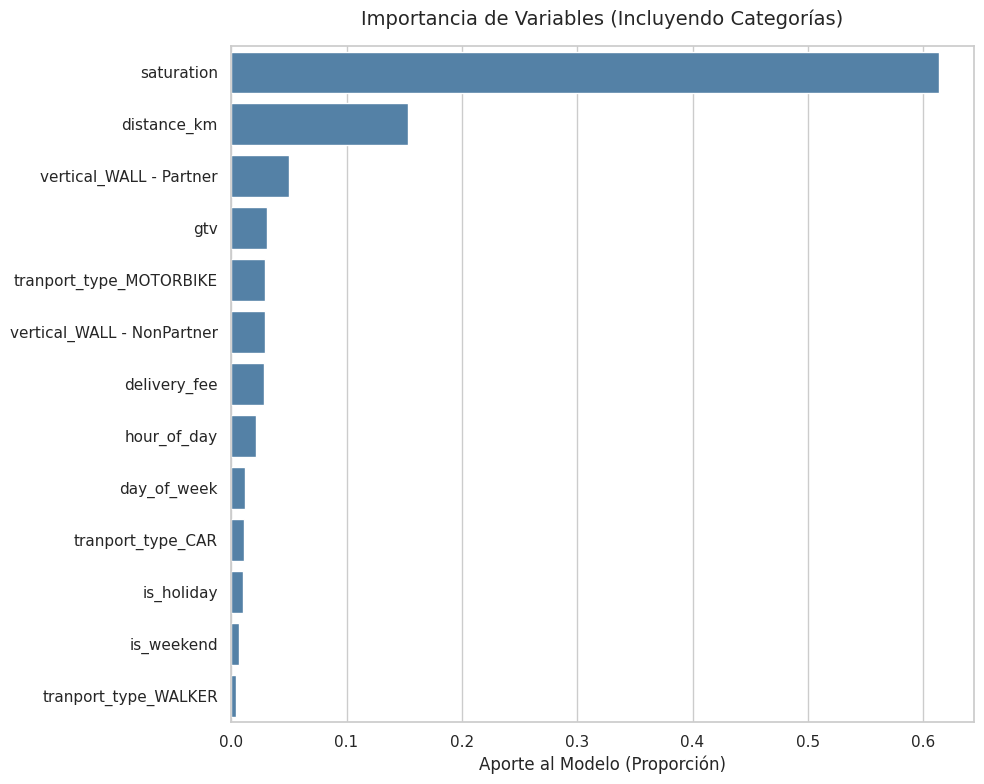

In [ ]:
# 6. Gráfico de Importancia
importancias = modelo_xgb_optimizado.feature_importances_
df_importancia = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))
sns.barplot(data=df_importancia, x='Importancia', y='Variable', color='steelblue')
plt.title('Importancia de Variables (Incluyendo Categorías)', fontsize=14, pad=15)
plt.xlabel('Aporte al Modelo (Proporción)')
plt.ylabel('')
plt.tight_layout()
plt.show()

código para extraer los "pesos" matemáticos que el algoritmo le ha dado a cada variable y graficarlos con un formato profesional, perfecto para tu defensa en la UPF BSM. Ejecuta esta celda a continuación de tu entrenamiento:

In [ ]:
# 1. Definimos SOLO las variables que han demostrado aportar valor real
columnas_features_top = [
    'saturation', 'distance_km', 'gtv', 'delivery_fee', 'hour_of_day',
    'tranport_type_MOTORBIKE', 'vertical_WALL - Partner', 'vertical_WALL - NonPartner'
]

# 2. Verificamos que existen en df_clean
features_reales_top = [col for col in columnas_features_top if col in df_clean.columns]

# 3. Redefinimos X y volvemos a separar Train/Test
X_top = df_clean[features_reales_top]
X_train_top, X_test_top, y_train, y_test = train_test_split(X_top, y, test_size=0.2, random_state=42)

# 4. Entrenamos el mismo modelo optimizado pero con menos variables
modelo_xgb_ligero = xgb.XGBRegressor(
    n_estimators=150, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror',
    random_state=42, n_jobs=-1
)

modelo_xgb_ligero.fit(X_train_top, y_train)

# 5. Evaluamos
predicciones_top = modelo_xgb_ligero.predict(X_test_top)
mae_top = mean_absolute_error(y_test, predicciones_top)
rmse_top = np.sqrt(mean_squared_error(y_test, predicciones_top))

print(f"MAE Modelo Ligero:  {mae_top:.2f} minutos")
print(f"RMSE Modelo Ligero: {rmse_top:.2f} minutos")

MAE Modelo Ligero:  6.27 minutos
RMSE Modelo Ligero: 7.80 minutos


In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Crear la nueva variable 'is_peak_hour' (inicializada en 0)
df_clean['is_peak_hour'] = 0

# Definimos las reglas de negocio para "Hora Punta"
# Recuerda que en pandas: Lunes=0, Martes=1, ..., Viernes=4, Sábado=5, Domingo=6

# Condición 1: Cenas de fin de semana (Viernes, Sábado y Domingo de 20:00 a 23:59)
cenas_finde = (df_clean['day_of_week'].isin([4, 5, 6])) & (df_clean['hour_of_day'].isin([20, 21, 22, 23]))

# Condición 2: Comidas de fin de semana (Sábado y Domingo de 13:00 a 15:59)
comidas_finde = (df_clean['day_of_week'].isin([5, 6])) & (df_clean['hour_of_day'].isin([13, 14, 15]))

# Aplicamos el valor 1 donde se cumplan las condiciones
df_clean.loc[cenas_finde | comidas_finde, 'is_peak_hour'] = 1

# 2. Nueva selección de variables (Eliminamos hour, day_of_week, is_weekend y metemos is_peak_hour)
columnas_features_peak = [
    'saturation', 'distance_km', 'gtv', 'delivery_fee',
    'is_peak_hour', # <-- NUEVA VARIABLE
    'tranport_type_MOTORBIKE', 'vertical_WALL - Partner', 'vertical_WALL - NonPartner'
]

features_reales_peak = [col for col in columnas_features_peak if col in df_clean.columns]

# 3. División y Entrenamiento
X_peak = df_clean[features_reales_peak]
y = df_clean['delivery_time_minutes']

X_train_peak, X_test_peak, y_train, y_test = train_test_split(X_peak, y, test_size=0.2, random_state=42)

# Usamos la misma configuración de 150 árboles para comparar manzanas con manzanas
modelo_xgb_peak = xgb.XGBRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

modelo_xgb_peak.fit(X_train_peak, y_train)

# 4. Evaluación
predicciones_peak = modelo_xgb_peak.predict(X_test_peak)

mae_peak = mean_absolute_error(y_test, predicciones_peak)
rmse_peak = np.sqrt(mean_squared_error(y_test, predicciones_peak))
r2_peak = r2_score(y_test, predicciones_peak)

print("=== RESULTADOS CON VARIABLE DE NEGOCIO (IS_PEAK_HOUR) ===")
print(f"MAE  (Error Absoluto Medio): {mae_peak:.2f} minutos")
print(f"RMSE (Penalización grave):   {rmse_peak:.2f} minutos")
print(f"R2   (Varianza Explicada):   {r2_peak*100:.2f} %")

=== RESULTADOS CON VARIABLE DE NEGOCIO (IS_PEAK_HOUR) ===
MAE  (Error Absoluto Medio): 6.30 minutos
RMSE (Penalización grave):   7.83 minutos
R2   (Varianza Explicada):   45.84 %


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Definir la "Malla" (Grid) de parámetros a explorar
# Le damos un abanico de opciones conservadoras y agresivas para que el algoritmo pruebe
param_grid = {
    'n_estimators': [100, 120, 150, 170, 200],
    'learning_rate': [0.01, 0.02, 0.04, 0.05, 0.07],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# 2. Inicializar el modelo base (vacío)
xgb_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

# 3. Configurar el motor de búsqueda automática
print("Iniciando la búsqueda de hiperparámetros. Esto puede tardar unos minutos...")
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=50,                           # Probará 50 combinaciones distintas
    scoring='neg_mean_absolute_error',   # Nuestro objetivo es minimizar el MAE
    cv=3,                                # Validación cruzada: entrena 3 veces por cada combinación para asegurar que no es suerte
    verbose=1,                           # Mostrará el progreso en pantalla
    random_state=42,
    n_jobs=-1                            # Usar todos los procesadores
)

# 4. Lanzar el entrenamiento masivo
random_search.fit(X_train_top, y_train)

# 5. Extraer el ganador absoluto
mejor_modelo = random_search.best_estimator_

print("\n¡Búsqueda completada con éxito!")
print("-" * 40)
print("Los mejores hiperparámetros matemáticos son:")
for parametro, valor in random_search.best_params_.items():
    print(f" - {parametro}: {valor}")
print("-" * 40)

# 6. Evaluar el modelo ganador contra nuestros datos de prueba
predicciones_optimas = mejor_modelo.predict(X_test_top)

mae_optimo = mean_absolute_error(y_test, predicciones_optimas)
rmse_optimo = np.sqrt(mean_squared_error(y_test, predicciones_optimas))
r2_optimo = r2_score(y_test, predicciones_optimas)

print("\n=== RESULTADOS DEFINITIVOS (MODELO LIGERO + GRID SEARCH) ===")
print(f"MAE  (Error Absoluto Medio): {mae_optimo:.2f} minutos")
print(f"RMSE (Penalización grave):   {rmse_optimo:.2f} minutos")
print(f"R2   (Varianza Explicada):   {r2_optimo*100:.2f} %")

Iniciando la búsqueda de hiperparámetros. Esto puede tardar unos minutos...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

¡Búsqueda completada con éxito!
----------------------------------------
Los mejores hiperparámetros matemáticos son:
 - subsample: 0.7
 - n_estimators: 100
 - max_depth: 5
 - learning_rate: 0.07
 - colsample_bytree: 0.7
----------------------------------------

=== RESULTADOS DEFINITIVOS (MODELO LIGERO + GRID SEARCH) ===
MAE  (Error Absoluto Medio): 6.28 minutos
RMSE (Penalización grave):   7.80 minutos
R2   (Varianza Explicada):   46.24 %


In [ ]:
# 1. Calcular el límite superior estadístico (Método de Tukey) dinámicamente
Q1 = df['delivery_time_minutes'].quantile(0.25)
Q3 = df['delivery_time_minutes'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

print(f"El Límite Superior de Tukey calculado es: {limite_superior:.2f} minutos")

# 2. Filtrar el dataset usando el límite matemático
df_clean = df[df['delivery_time_minutes'] <= limite_superior].copy()

# 3. One-Hot Encoding (Asegurar que las variables de texto sean numéricas)
columnas_categoricas = []
if 'tranport_type' in df_clean.columns: columnas_categoricas.append('tranport_type')
if 'vertical' in df_clean.columns: columnas_categoricas.append('vertical')

if columnas_categoricas:
    df_clean = pd.get_dummies(df_clean, columns=columnas_categoricas, drop_first=False)
    for col in df_clean.columns:
        if df_clean[col].dtype == 'bool':
            df_clean[col] = df_clean[col].astype(int)

# 4. Seleccionar el "Top 8" de variables del Modelo Ligero
columnas_features_top = [
    'saturation', 'distance_km', 'gtv', 'delivery_fee', 'hour_of_day',
    'tranport_type_MOTORBIKE', 'vertical_WALL - Partner', 'vertical_WALL - NonPartner'
]

features_reales_top = [col for col in columnas_features_top if col in df_clean.columns]

# 5. Dividir y Entrenar
X = df_clean[features_reales_top]
y = df_clean['delivery_time_minutes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_xgb_final = xgb.XGBRegressor(
    n_estimators=200, learning_rate=0.07, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror',
    random_state=42, n_jobs=-1
)
modelo_xgb_final.fit(X_train, y_train)

# 6. Resultados Finales
predicciones_finales = modelo_xgb_final.predict(X_test)
mae = mean_absolute_error(y_test, predicciones_finales)
rmse = np.sqrt(mean_squared_error(y_test, predicciones_finales))
r2 = r2_score(y_test, predicciones_finales)

print("\n=== RESULTADOS DEFINITIVOS (MÉTODO DE TUKEY) ===")
print(f"MAE:  {mae:.2f} minutos")
print(f"RMSE: {rmse:.2f} minutos")
print(f"R2:   {r2*100:.2f} %")

El Límite Superior de Tukey calculado es: 72.23 minutos

=== RESULTADOS DEFINITIVOS (MÉTODO DE TUKEY) ===
MAE:  6.71 minutos
RMSE: 8.36 minutos
R2:   54.28 %


In [ ]:
# 1. Calcular el límite superior estadístico (Método de Tukey)
Q1 = df['delivery_time_minutes'].quantile(0.25)
Q3 = df['delivery_time_minutes'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

# 2. Filtrar el dataset
df_clean = df[df['delivery_time_minutes'] <= limite_superior].copy()

# 3. One-Hot Encoding
columnas_categoricas = ['tranport_type', 'vertical']
df_clean = pd.get_dummies(df_clean, columns=columnas_categoricas, drop_first=False)
for col in df_clean.columns:
    if df_clean[col].dtype == 'bool':
        df_clean[col] = df_clean[col].astype(int)

# 4. Seleccionar variables: Reemplazamos 'distance_km' por coordenadas
columnas_features_geo = [
    'saturation', 'gtv', 'delivery_fee', 'hour_of_day',
    'pickup_latitude', 'pickup_longitude',
    'delivery_latitude', 'delivery_longitude',
    'tranport_type_MOTORBIKE', 'vertical_WALL - Partner', 'vertical_WALL - NonPartner'
]

features_reales = [col for col in columnas_features_geo if col in df_clean.columns]

# 5. Dividir y Entrenar
X = df_clean[features_reales]
y = df_clean['delivery_time_minutes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_xgb_geo = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.07, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror',
    random_state=42, n_jobs=-1
)
modelo_xgb_geo.fit(X_train, y_train)

# 6. Resultados Finales
predicciones = modelo_xgb_geo.predict(X_test)
mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))
r2 = r2_score(y_test, predicciones)

print("\n=== RESULTADOS ")
print(f"MAE:  {mae:.2f} minutos")
print(f"RMSE: {rmse:.2f} minutos")
print(f"R2:   {r2*100:.2f} %")


=== RESULTADOS 
MAE:  6.68 minutos
RMSE: 8.31 minutos
R2:   54.77 %


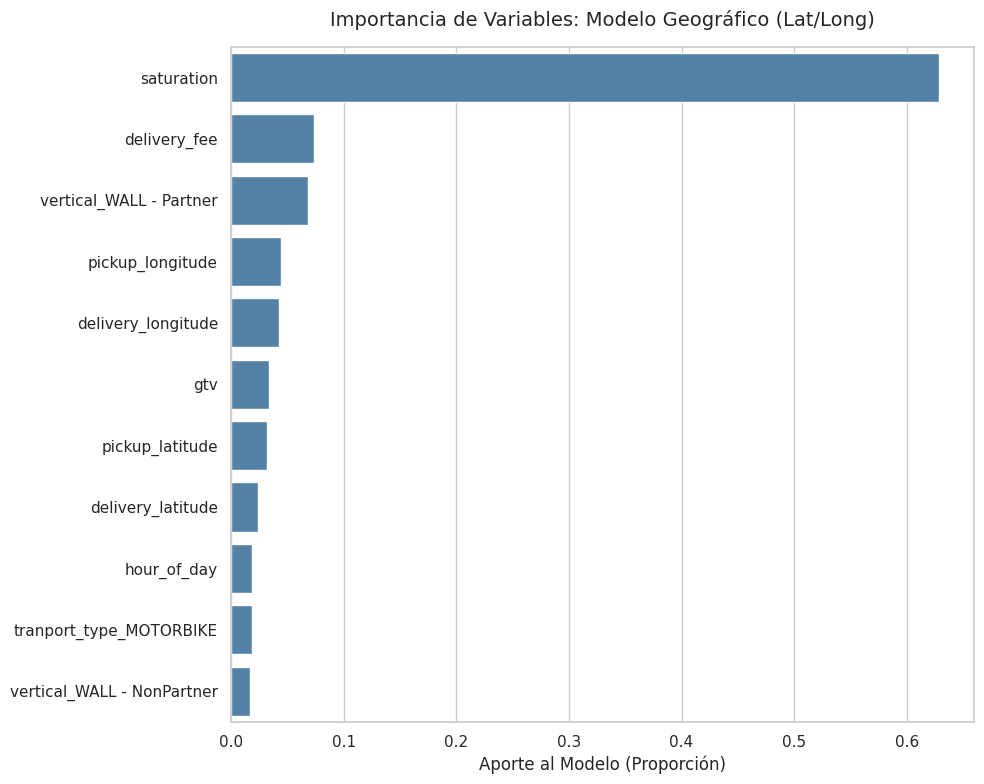

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extraer importancias del modelo entrenado
importancias = modelo_xgb_geo.feature_importances_
nombres_variables = X_train.columns

# Crear DataFrame y ordenar
df_imp = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Configurar visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))
sns.barplot(data=df_imp, x='Importancia', y='Variable', color='steelblue')

plt.title('Importancia de Variables: Modelo Geográfico (Lat/Long)', fontsize=14, pad=15)
plt.xlabel('Aporte al Modelo (Proporción)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

In [73]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. CARGA Y PREPARACIÓN DE DATOS
df = pd.read_csv('glovo_ops_data_final.csv')

# Transformación de tiempos y cálculo del target (ETA)
df['activation_time_local'] = pd.to_datetime(df['activation_time_local'])
df['delivery_time_local'] = pd.to_datetime(df['delivery_time_local'])
df['delivery_time_minutes'] = (df['delivery_time_local'] - df['activation_time_local']).dt.total_seconds() / 60

# Ingeniería de variables temporales
df['hour_of_day'] = df['activation_time_local'].dt.hour

# 2. LIMPIEZA ESTADÍSTICA AVANZADA (MÉTODO DE TUKEY)
# Aplicamos el límite superior para eliminar ruidos operativos extremos
Q1 = df['delivery_time_minutes'].quantile(0.25)
Q3 = df['delivery_time_minutes'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

df_clean = df[df['delivery_time_minutes'] <= limite_superior].copy()
print(f"Límite de Tukey: {limite_superior:.2f} min. Registros filtrados: {len(df) - len(df_clean)}")

# Calcular la distancia lineal aproximada (Fórmula de la hipotenusa adaptada a KM)
# Multiplicamos por 111 para convertir la diferencia de grados a kilómetros aproximados
df_clean['distance_km'] = np.sqrt(
    (df_clean['pickup_latitude'] - df_clean['delivery_latitude'])**2 +
    (df_clean['pickup_longitude'] - df_clean['delivery_longitude'])**2
) * 111

print(f"Variable 'distance_km' creada correctamente. Media: {df_clean['distance_km'].mean():.2f} km")

# 3. ENCODING DE VARIABLES CATEGÓRICAS
# Transformamos transport_type y vertical en columnas numéricas (0/1)
df_clean = pd.get_dummies(df_clean, columns=['tranport_type', 'vertical'], drop_first=False)

# Aseguramos formato entero para las nuevas columnas booleanas
for col in df_clean.columns:
    if df_clean[col].dtype == 'bool':
        df_clean[col] = df_clean[col].astype(int)

# 4. SELECCIÓN DE VARIABLES FINALES (TOP 10 - MODELO GEOGRÁFICO)
# Excluimos delivery_fee por redundancia y riesgo de multicolinealidad
features = [
    'saturation',
    'distance_km',
    'gtv',
    'hour_of_day',
    'pickup_latitude',
    'pickup_longitude',
    'delivery_latitude',
    'delivery_longitude',
    'tranport_type_MOTORBIKE',
    'vertical_WALL - Partner',
    'vertical_WALL - NonPartner'
]

X = df_clean[features]
y = df_clean['delivery_time_minutes']

# 5. DIVISIÓN DEL DATASET (80% Entrenamiento / 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. CONFIGURACIÓN Y ENTRENAMIENTO (XGBOOST)
# Parámetros optimizados tras el proceso de Grid Search
modelo_final = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.07,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

modelo_final.fit(X_train, y_train)

# 7. EVALUACIÓN DE RENDIMIENTO
predicciones = modelo_final.predict(X_test)

mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))
r2 = r2_score(y_test, predicciones)

print("\n" + "="*40)
print("   RESULTADOS DEL MODELO DE PRODUCCIÓN")
print("="*40)
print(f"MAE (Error Medio):    {mae:.2f} minutos")
print(f"RMSE (Error Grave):   {rmse:.2f} minutos")
print(f"R2 (Varianza Expl.):  {r2*100:.2f} %")
print("="*40)
print("\n" + "="*50)
print("   RESULTADOS EXTENDIDOS DEL MODELO DE PRODUCCIÓN")
print("="*50)
print(f"RESUMEN DE ERRORES:")
print(f"MAE (Error Medio Absoluto):      {mae:.2f} min")
print(f"MedAE (Error Mediano Absoluto):   {medae:.2f} min")
print(f"RMSE (Raíz del Error Cuadrático): {rmse:.2f} min")
print(f"MAPE (Error Porcentual Medio):    {mape*100:.2f} %")
print(f"Error Máximo registrado:          {max_err:.2f} min")
print("-" * 50)
print(f"CAPACIDAD PREDICTIVA:")
print(f"R2 (Coef. de Determinación):     {r2*100:.2f} %")
print(f"R2 Ajustado:                     {r2_adj*100:.2f} %")
print(f"Varianza Explicada:              {evs*100:.2f} %")
print("-" * 50)
print(f"MÉTRICAS DE NEGOCIO (HIT RATE):")
print(f"Predicciones dentro de +/- 5 min: {within_5_min:.2f} %")
print(f"Predicciones dentro de +/- 10 min:{within_10_min:.2f} %")
print("="*50)

Límite de Tukey: 72.23 min. Registros filtrados: 2406
Variable 'distance_km' creada correctamente. Media: 3.12 km

   RESULTADOS DEL MODELO DE PRODUCCIÓN
MAE (Error Medio):    6.65 minutos
RMSE (Error Grave):   8.28 minutos
R2 (Varianza Expl.):  55.15 %

   RESULTADOS EXTENDIDOS DEL MODELO DE PRODUCCIÓN
RESUMEN DE ERRORES:
MAE (Error Medio Absoluto):      6.65 min


NameError: name 'medae' is not defined

In [70]:
import pandas as pd

# 1. Asegurar formato de fecha
df['activation_time_local'] = pd.to_datetime(df['activation_time_local'])
df['courier_started_order_local'] = pd.to_datetime(df['courier_started_order_local'])

# 2. Filtrar las filas con la anomalía
anomalias = df[df['activation_time_local'] > df['courier_started_order_local']].copy()

# 3. Analizar por Vertical (Tipo de cliente/negocio)
print("Anomalías por Tipo de Vertical:")
print(anomalias['vertical'].value_counts(normalize=True) * 100)

# 4. Analizar los Top 10 establecimientos con más anomalías
print("\nTop 10 Tiendas con esta característica:")
print(anomalias['store_name'].value_counts().head(10))

# 5. Calcular la diferencia promedio en segundos para ver si es latencia técnica
diff_avg = (anomalias['activation_time_local'] - anomalias['courier_started_order_local']).dt.total_seconds().mean()
print(f"\nDiferencia promedio: {diff_avg:.2f} segundos")

Anomalías por Tipo de Vertical:
vertical
WALL - Partner       64.408311
COURIER              18.988257
WALL - NonPartner    16.603433
Name: proportion, dtype: float64

Top 10 Tiendas con esta característica:
store_name
Carrefour                  2655
Epicerie Générale           988
Starbucks                   885
McDonald's                  550
Pharmacie                   529
Miznon                      408
Bozen                       210
Espace bar                  192
Aux Merveilleux de Fred     191
Burger King                 184
Name: count, dtype: int64

Diferencia promedio: 105.19 segundos


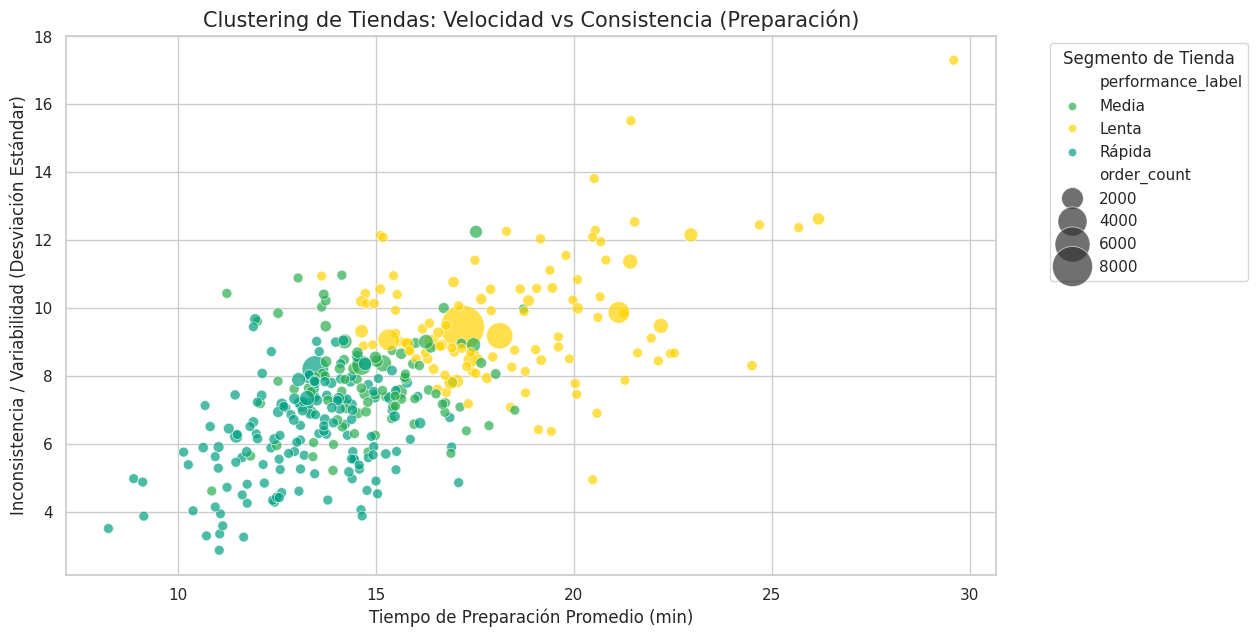

Resumen de Segmentación de Tiendas:
                   avg_prep_time  avg_gtv  order_count
performance_label                                     
Lenta                      18.47    25.17        26016
Media                      14.89    39.58        11477
Rápida                     13.20    23.55        13251


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Cargar los datos del archivo original
df = pd.read_csv('glovo_ops_data_final.csv')

# 2. Preparación de variables de tiempo
df['courier_started_order_local'] = pd.to_datetime(df['courier_started_order_local'])
df['pickup_time_local'] = pd.to_datetime(df['pickup_time_local'])

# 3. Calcular el tiempo de preparación (en minutos)
df['prep_time'] = (df['pickup_time_local'] - df['courier_started_order_local']).dt.total_seconds() / 60

# 4. Limpieza de datos: eliminamos tiempos negativos o irreales (más de 3 horas)
df_clean = df[(df['prep_time'] > 0) & (df['prep_time'] < 180)].copy()

# 5. Agregación de métricas por tienda[cite: 1]
# Filtramos tiendas con al menos 10 pedidos para asegurar relevancia estadística
store_metrics = df_clean.groupby('store_name').agg(
    avg_prep_time=('prep_time', 'mean'),
    std_prep_time=('prep_time', 'std'),
    order_count=('order_id', 'count'),
    avg_gtv=('gtv', 'mean')
).dropna()

store_metrics = store_metrics[store_metrics['order_count'] >= 10]

# 6. Selección de características y Normalización[cite: 1]
features = ['avg_prep_time', 'std_prep_time', 'avg_gtv']
X = store_metrics[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Ejecución de K-Means (3 clusters: Rápida, Media, Lenta)[cite: 1]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
store_metrics['cluster'] = kmeans.fit_predict(X_scaled)

# 8. Etiquetado lógico de los clusters según el tiempo medio[cite: 1]
cluster_means = store_metrics.groupby('cluster')['avg_prep_time'].mean().sort_values()
label_map = {
    cluster_means.index[0]: 'Rápida',
    cluster_means.index[1]: 'Media',
    cluster_means.index[2]: 'Lenta'
}
store_metrics['performance_label'] = store_metrics['cluster'].map(label_map)

# 9. Visualización de resultados[cite: 1]
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
scatter = sns.scatterplot(
    data=store_metrics,
    x='avg_prep_time',
    y='std_prep_time',
    hue='performance_label',
    size='order_count',
    sizes=(50, 1000),
    alpha=0.7,
    palette={'Rápida': '#00A082', 'Media': '#2AAD4F', 'Lenta': '#FFD300'}
)

plt.title('Clustering de Tiendas: Velocidad vs Consistencia (Preparación)', fontsize=15)
plt.xlabel('Tiempo de Preparación Promedio (min)', fontsize=12)
plt.ylabel('Inconsistencia / Variabilidad (Desviación Estándar)', fontsize=12)
plt.legend(title='Segmento de Tienda', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 10. Mostrar resumen de los grupos[cite: 1]
print("Resumen de Segmentación de Tiendas:")
print(store_metrics.groupby('performance_label').agg({
    'avg_prep_time': 'mean',
    'avg_gtv': 'mean',
    'order_count': 'sum'
}).round(2))

In [74]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             median_absolute_error, mean_absolute_percentage_error,
                             explained_variance_score, max_error)

# 1. CARGA Y PREPARACIÓN DE DATOS
# Cargando datos desde el archivo original
df = pd.read_csv('glovo_ops_data_final.csv')

# Transformación de tiempos y cálculo del target (ETA)
df['activation_time_local'] = pd.to_datetime(df['activation_time_local'])
df['delivery_time_local'] = pd.to_datetime(df['delivery_time_local'])
df['delivery_time_minutes'] = (df['delivery_time_local'] - df['activation_time_local']).dt.total_seconds() / 60

# Ingeniería de variables temporales
df['hour_of_day'] = df['activation_time_local'].dt.hour

# 2. LIMPIEZA ESTADÍSTICA AVANZADA (MÉTODO DE TUKEY)
Q1 = df['delivery_time_minutes'].quantile(0.25)
Q3 = df['delivery_time_minutes'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

df_clean = df[df['delivery_time_minutes'] <= limite_superior].copy()
print(f"Límite de Tukey: {limite_superior:.2f} min. Registros filtrados: {len(df) - len(df_clean)}")

# Calcular la distancia lineal aproximada[cite: 1]
df_clean['distance_km'] = np.sqrt(
    (df_clean['pickup_latitude'] - df_clean['delivery_latitude'])**2 +
    (df_clean['pickup_longitude'] - df_clean['delivery_longitude'])**2
) * 111

print(f"Variable 'distance_km' creada correctamente. Media: {df_clean['distance_km'].mean():.2f} km")

# 3. ENCODING DE VARIABLES CATEGÓRICAS[cite: 1]
df_clean = pd.get_dummies(df_clean, columns=['tranport_type', 'vertical'], drop_first=False)

for col in df_clean.columns:
    if df_clean[col].dtype == 'bool':
        df_clean[col] = df_clean[col].astype(int)

# 4. SELECCIÓN DE VARIABLES FINALES[cite: 1]
features = [
    'saturation', 'distance_km', 'gtv', 'hour_of_day',
    'pickup_latitude', 'pickup_longitude', 'delivery_latitude', 'delivery_longitude',
    'tranport_type_MOTORBIKE', 'vertical_WALL - Partner', 'vertical_WALL - NonPartner'
]

X = df_clean[features]
y = df_clean['delivery_time_minutes']

# 5. DIVISIÓN DEL DATASET
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. CONFIGURACIÓN Y ENTRENAMIENTO (XGBOOST)[cite: 1]
modelo_final = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.07,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

modelo_final.fit(X_train, y_train)

# 7. EVALUACIÓN DE RENDIMIENTO EXTENDIDA
predicciones = modelo_final.predict(X_test)

# Métricas base
mae = mean_absolute_error(y_test, predicciones)
mse = mean_squared_error(y_test, predicciones)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predicciones)

# Métricas adicionales
medae = median_absolute_error(y_test, predicciones)
mape = mean_absolute_percentage_error(y_test, predicciones)
evs = explained_variance_score(y_test, predicciones)
max_err = max_error(y_test, predicciones)

# R2 Ajustado
n = X_test.shape[0] # número de muestras
p = X_test.shape[1] # número de predictores
r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Precisión dentro de umbrales (Hit Rate)
errors = np.abs(y_test - predicciones)
within_5_min = np.mean(errors <= 5) * 100
within_10_min = np.mean(errors <= 10) * 100

print("\n" + "="*50)
print("   RESULTADOS EXTENDIDOS DEL MODELO DE PRODUCCIÓN")
print("="*50)
print(f"RESUMEN DE ERRORES:")
print(f"MAE (Error Medio Absoluto):      {mae:.2f} min")
print(f"MedAE (Error Mediano Absoluto):   {medae:.2f} min")
print(f"RMSE (Raíz del Error Cuadrático): {rmse:.2f} min")
print(f"MAPE (Error Porcentual Medio):    {mape*100:.2f} %")
print(f"Error Máximo registrado:          {max_err:.2f} min")
print("-" * 50)
print(f"CAPACIDAD PREDICTIVA:")
print(f"R2 (Coef. de Determinación):     {r2*100:.2f} %")
print(f"R2 Ajustado:                     {r2_adj*100:.2f} %")
print(f"Varianza Explicada:              {evs*100:.2f} %")
print("-" * 50)
print(f"MÉTRICAS DE NEGOCIO (HIT RATE):")
print(f"Predicciones dentro de +/- 5 min: {within_5_min:.2f} %")
print(f"Predicciones dentro de +/- 10 min:{within_10_min:.2f} %")
print("="*50)

Límite de Tukey: 72.23 min. Registros filtrados: 2406
Variable 'distance_km' creada correctamente. Media: 3.12 km

   RESULTADOS EXTENDIDOS DEL MODELO DE PRODUCCIÓN
RESUMEN DE ERRORES:
MAE (Error Medio Absoluto):      6.65 min
MedAE (Error Mediano Absoluto):   5.73 min
RMSE (Raíz del Error Cuadrático): 8.28 min
MAPE (Error Porcentual Medio):    20.89 %
Error Máximo registrado:          31.04 min
--------------------------------------------------
CAPACIDAD PREDICTIVA:
R2 (Coef. de Determinación):     55.15 %
R2 Ajustado:                     55.11 %
Varianza Explicada:              55.15 %
--------------------------------------------------
MÉTRICAS DE NEGOCIO (HIT RATE):
Predicciones dentro de +/- 5 min: 43.79 %
Predicciones dentro de +/- 10 min:78.19 %
